# Experiments

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
import inspect
import os
import warnings
import time

from tests import *

from conformal import *

from sampler import sampler_perturb_2ST, sampler_perturb_IndT

os.makedirs('results', exist_ok=True)

jax.config.update("jax_enable_x64", True)

jnp.array([1, ]).device

CudaDevice(id=0)

In [2]:
%load_ext autoreload
%autoreload 2

# Experiment 1a

Running experiment with B=10, trials=20000, m=50, n=50...


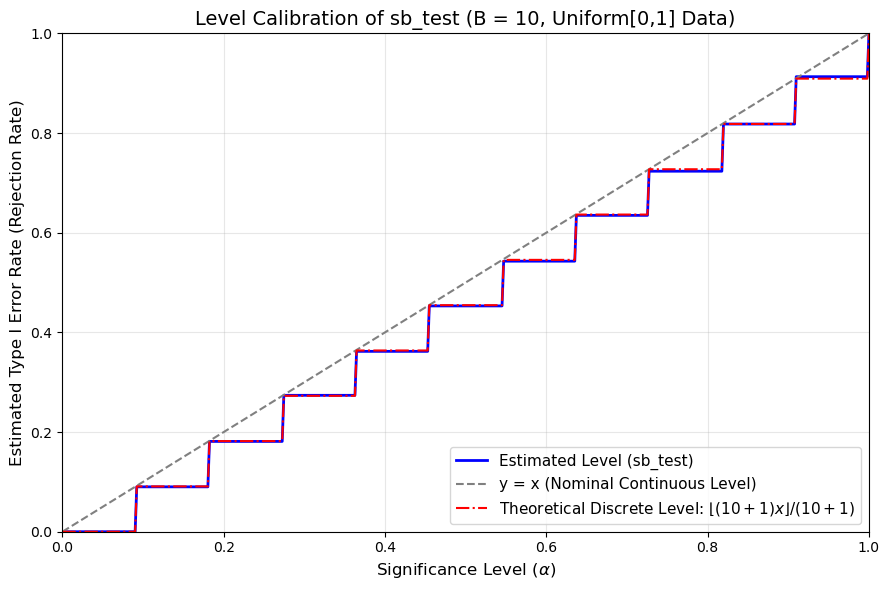

Saved arrays to results/experiment_1_sb.npz


In [3]:
# level SB

def run_experiment(B=10, n_trials=20000, m=50, n=50):
    """
    Runs a Type I error (level) experiment for the sb_test.
    """
    print(f"Running experiment with B={B}, trials={n_trials}, m={m}, n={n}...")
    B_val = B
    
    def multi_stats(data):
        X, Y = data
        diff_mean = jnp.abs(jnp.mean(X) - jnp.mean(Y))
        diff_median = jnp.abs(jnp.median(X) - jnp.median(Y))
        return jnp.stack([diff_mean, diff_median])

    def single_trial(key):
        k_x, k_y, k_test = jax.random.split(key, 3)
        X = jax.random.uniform(k_x, shape=(m, 1))
        Y = jax.random.uniform(k_y, shape=(n, 1))
        p_val, _ = sb_test(
            key=k_test, 
            data=(X, Y), 
            multi_stats=multi_stats, 
            framework='two sample', 
            B=B, 
            alpha=0.05
        )
        return p_val

    # Computations
    batched_trials = jax.jit(jax.vmap(single_trial))
    master_key = jax.random.PRNGKey(42)
    trial_keys = jax.random.split(master_key, n_trials)
    p_values = batched_trials(trial_keys) 
    alphas = jnp.linspace(0, 1, 500)
    rejections = p_values[:, None] <= alphas[None, :]
    estimated_levels = jnp.mean(rejections, axis=0)
        
    # Plotting
    plt.figure(figsize=(9, 6))
    plt.plot(alphas, estimated_levels, label='Estimated Level (sb_test)', color='blue', linewidth=2)
    plt.plot(alphas, alphas, '--', color='gray', label='y = x (Nominal Continuous Level)')
    theoretical_levels = np.floor((B_val + 1) * alphas) / (B_val + 1)
    plt.plot(alphas, theoretical_levels, '-.', color='red', 
             label=f'Theoretical Discrete Level: $\\lfloor({B_val}+1)x\\rfloor / ({B_val}+1)$')
    
    # Formatting
    plt.xlabel(r'Significance Level ($\alpha$)', fontsize=12)
    plt.ylabel('Estimated Type I Error Rate (Rejection Rate)', fontsize=12)
    plt.title(f'Level Calibration of sb_test (B = {B_val}, Uniform[0,1] Data)', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()
    
    # Create the results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays to a compressed .npz file
    filename = f'results/experiment_1_sb.npz'
    np.savez_compressed(
        filename, 
        alphas=np.array(alphas), 
        estimated_levels=np.array(estimated_levels), 
        theoretical_levels=np.array(theoretical_levels)
    )
    print(f"Saved arrays to {filename}")

if __name__ == '__main__':
    run_experiment()

Running experiment with B=10, trials=20000, m=50, n=50...


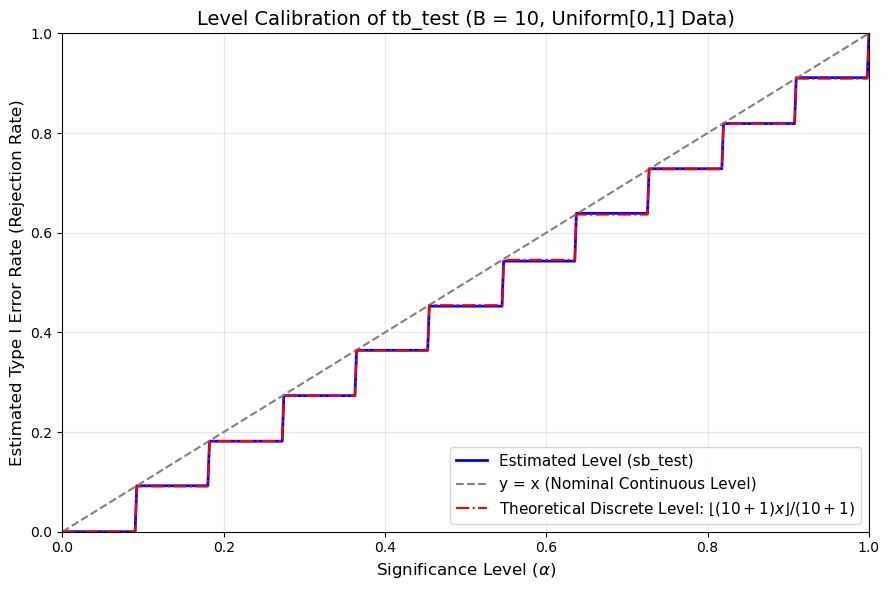

Saved arrays to results/experiment_1_tb.npz


In [4]:
# level TB

def run_experiment(B=10, n_trials=20000, m=50, n=50):
    """
    Runs a Type I error (level) experiment for the tb_test.
    """
    print(f"Running experiment with B={B}, trials={n_trials}, m={m}, n={n}...")
    B_val = B
    
    def multi_stats(data):
        X, Y = data
        diff_mean = jnp.abs(jnp.mean(X) - jnp.mean(Y))
        diff_median = jnp.abs(jnp.median(X) - jnp.median(Y))
        return jnp.stack([diff_mean, diff_median])

    def single_trial(key):
        k_x, k_y, k_test = jax.random.split(key, 3)
        X = jax.random.uniform(k_x, shape=(m, 1))
        Y = jax.random.uniform(k_y, shape=(n, 1))
        p_val, _ = tb_test(
            key=k_test, 
            data=(X, Y), 
            multi_stats=multi_stats, 
            framework='two sample', 
            B=B, 
            alpha=0.05
        )
        return p_val

    # Computations
    batched_trials = jax.jit(jax.vmap(single_trial))
    master_key = jax.random.PRNGKey(42)
    trial_keys = jax.random.split(master_key, n_trials)
    p_values = batched_trials(trial_keys) 
    alphas = jnp.linspace(0, 1, 500)
    rejections = p_values[:, None] <= alphas[None, :]
    estimated_levels = jnp.mean(rejections, axis=0)
        
    # Plotting
    plt.figure(figsize=(9, 6))
    plt.plot(alphas, estimated_levels, label='Estimated Level (sb_test)', color='blue', linewidth=2)
    plt.plot(alphas, alphas, '--', color='gray', label='y = x (Nominal Continuous Level)')
    theoretical_levels = np.floor((B_val + 1) * alphas) / (B_val + 1)
    plt.plot(alphas, theoretical_levels, '-.', color='red', 
             label=f'Theoretical Discrete Level: $\\lfloor({B_val}+1)x\\rfloor / ({B_val}+1)$')
    
    # Formatting
    plt.xlabel(r'Significance Level ($\alpha$)', fontsize=12)
    plt.ylabel('Estimated Type I Error Rate (Rejection Rate)', fontsize=12)
    plt.title(f'Level Calibration of tb_test (B = {B_val}, Uniform[0,1] Data)', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

    # Create the results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays to a compressed .npz file
    filename = f'results/experiment_1_tb.npz'
    np.savez_compressed(
        filename, 
        alphas=np.array(alphas), 
        estimated_levels=np.array(estimated_levels), 
        theoretical_levels=np.array(theoretical_levels)
    )
    print(f"Saved arrays to {filename}")

if __name__ == '__main__':
    run_experiment()

Running experiment with B=10, trials=20000, m=50, n=50...


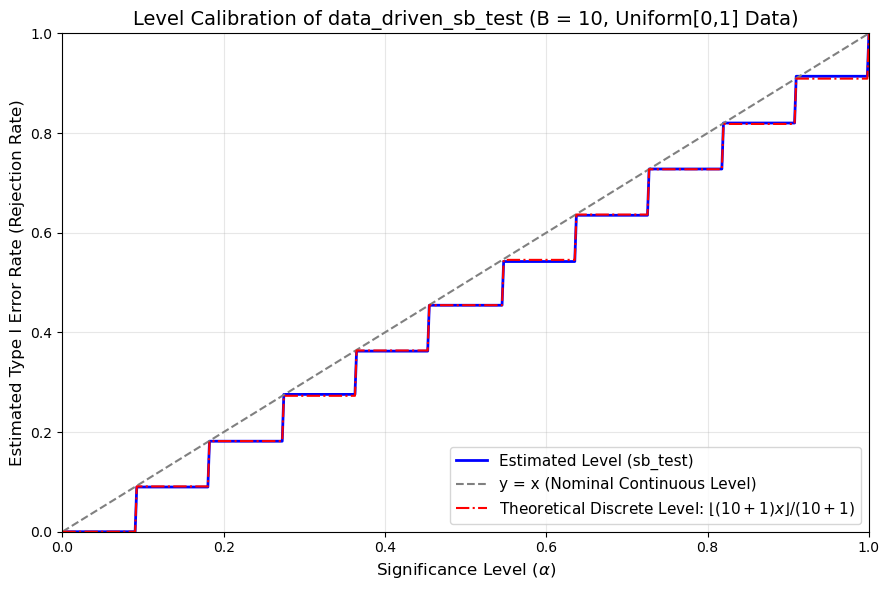

Saved arrays to results/experiment_1_ddsb.npz


In [5]:
# level data_driven_SB

def run_experiment(B=10, n_trials=20000, m=50, n=50):
    """
    Runs a Type I error (level) experiment for the data_driven_sb_test.
    """
    print(f"Running experiment with B={B}, trials={n_trials}, m={m}, n={n}...")
    B_val = B
    
    def multi_stats(data):
        X, Y = data
        diff_mean = jnp.abs(jnp.mean(X) - jnp.mean(Y))
        diff_median = jnp.abs(jnp.median(X) - jnp.median(Y))
        return jnp.stack([diff_mean, diff_median])

    def single_trial(key):
        k_x, k_y, k_test = jax.random.split(key, 3)
        X = jax.random.uniform(k_x, shape=(m, 1))
        Y = jax.random.uniform(k_y, shape=(n, 1))
        p_val, _ = data_driven_sb_test(
            key=k_test, 
            data=(X, Y), 
            multi_stats=multi_stats, 
            framework='two sample', 
            B=B, 
            alpha=0.05
        )
        return p_val

    # Computations
    batched_trials = jax.jit(jax.vmap(single_trial))
    master_key = jax.random.PRNGKey(42)
    trial_keys = jax.random.split(master_key, n_trials)
    p_values = batched_trials(trial_keys)
    alphas = jnp.linspace(0, 1, 500)
    rejections = p_values[:, None] <= alphas[None, :]
    estimated_levels = jnp.mean(rejections, axis=0)
    
    # Plotting
    plt.figure(figsize=(9, 6))
    plt.plot(alphas, estimated_levels, label='Estimated Level (sb_test)', color='blue', linewidth=2)
    plt.plot(alphas, alphas, '--', color='gray', label='y = x (Nominal Continuous Level)')
    theoretical_levels = np.floor((B_val + 1) * alphas) / (B_val + 1)
    plt.plot(alphas, theoretical_levels, '-.', color='red', 
             label=f'Theoretical Discrete Level: $\\lfloor({B_val}+1)x\\rfloor / ({B_val}+1)$')
    
    # Formatting
    plt.xlabel(r'Significance Level ($\alpha$)', fontsize=12)
    plt.ylabel('Estimated Type I Error Rate (Rejection Rate)', fontsize=12)
    plt.title(f'Level Calibration of data_driven_sb_test (B = {B_val}, Uniform[0,1] Data)', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

    # Create the results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays to a compressed .npz file
    filename = f'results/experiment_1_ddsb.npz'
    np.savez_compressed(
        filename, 
        alphas=np.array(alphas), 
        estimated_levels=np.array(estimated_levels), 
        theoretical_levels=np.array(theoretical_levels)
    )
    print(f"Saved arrays to {filename}")

if __name__ == '__main__':
    run_experiment()

Running maxT_test experiment with B=10, trials=20000, m=50, n=50...


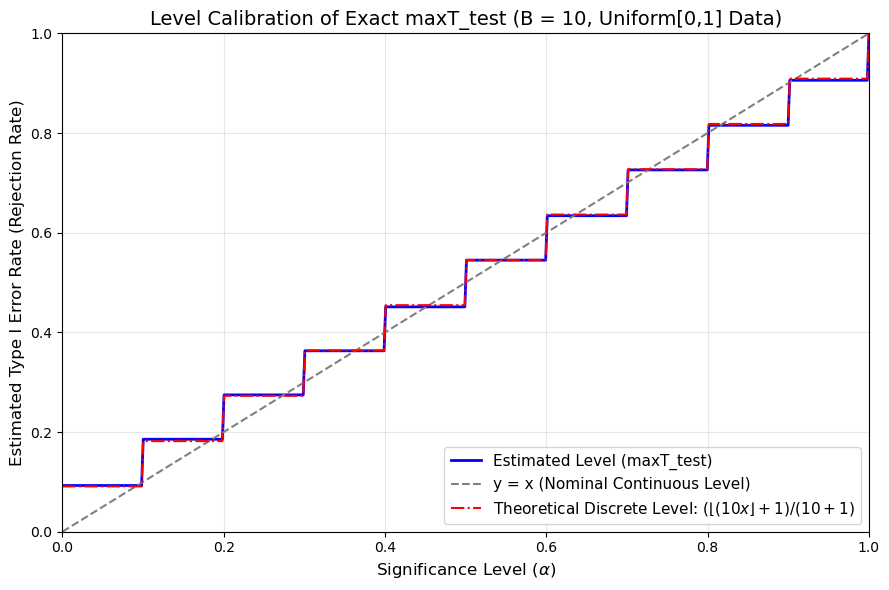

Saved arrays to results/experiment_1_maxT.npz


In [6]:
# Level MaxT

def run_experiment(B=10, n_trials=20000, m=50, n=50):
    """
    Runs a Type I error (level) experiment for the maxT_test.
    """
    print(f"Running maxT_test experiment with B={B}, trials={n_trials}, m={m}, n={n}...")
    B_val = B
    
    def multi_stats(data):
        X, Y = data
        diff_mean = jnp.abs(jnp.mean(X) - jnp.mean(Y))
        diff_median = jnp.abs(jnp.median(X) - jnp.median(Y))
        return jnp.stack([diff_mean, ])

    alphas = jnp.linspace(0, 1, 500)

    def evaluate_alpha(alpha, key, X, Y):
        _, output = maxT_test(
            key=key, 
            data=(X, Y), 
            multi_stats=multi_stats, 
            framework='two sample', 
            B=B, 
            alpha=alpha
        )
        return output

    def single_trial(key):
        k_x, k_y, k_test = jax.random.split(key, 3)
        X = jax.random.uniform(k_x, shape=(m, 1))
        Y = jax.random.uniform(k_y, shape=(n, 1))
        eval_all_alphas = jax.vmap(evaluate_alpha, in_axes=(0, None, None, None))
        return eval_all_alphas(alphas, k_test, X, Y)

    # Computations
    batched_trials = jax.jit(jax.vmap(single_trial))
    master_key = jax.random.PRNGKey(42)
    trial_keys = jax.random.split(master_key, n_trials)
    rejections = batched_trials(trial_keys)
    estimated_levels = jnp.mean(rejections, axis=0)
    
    # Plotting
    plt.figure(figsize=(9, 6))
    plt.plot(alphas, estimated_levels, label='Estimated Level (maxT_test)', color='blue', linewidth=2)
    plt.plot(alphas, alphas, '--', color='gray', label='y = x (Nominal Continuous Level)')
    theoretical_levels = np.floor((B_val * alphas) + 1) / (B_val + 1)
    plt.plot(alphas, theoretical_levels, '-.', color='red', 
             label=f'Theoretical Discrete Level: $(\\lfloor({B_val}x\\rfloor + 1) / ({B_val}+1)$')
    
    # Formatting
    plt.xlabel(r'Significance Level ($\alpha$)', fontsize=12)
    plt.ylabel('Estimated Type I Error Rate (Rejection Rate)', fontsize=12)
    plt.title(f'Level Calibration of Exact maxT_test (B = {B_val}, Uniform[0,1] Data)', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

    # Create the results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays to a compressed .npz file
    filename = f'results/experiment_1_maxT.npz'
    np.savez_compressed(
        filename, 
        alphas=np.array(alphas), 
        estimated_levels=np.array(estimated_levels), 
        theoretical_levels=np.array(theoretical_levels)
    )
    print(f"Saved arrays to {filename}")


if __name__ == '__main__':
    run_experiment()

# Experiment 2a

Running Deterministic Goldilocks Subspace Isolation
(m=100, n=100, D=20000, B=199, alpha=0.05)
------------------------------------------------------------------------------------------
d_shifted  | Shift Val  | L1 Power   | L4 Power   | Linf Power | SB Power   | TB Power  
------------------------------------------------------------------------------------------
1          | 1.1000     | 0.06       | 0.17       | 1.00       | 1.00       | 0.99      
2          | 1.0661     | 0.07       | 0.29       | 1.00       | 0.99       | 0.99      
4          | 1.0197     | 0.06       | 0.59       | 1.00       | 0.88       | 0.88      
8          | 0.9494     | 0.11       | 0.89       | 0.44       | 0.76       | 0.75      
16         | 0.8476     | 0.20       | 0.97       | 0.05       | 0.93       | 0.93      
32         | 0.7132     | 0.35       | 0.97       | 0.05       | 0.92       | 0.92      
64         | 0.5572     | 0.58       | 0.84       | 0.05       | 0.75       | 0.74      
128        

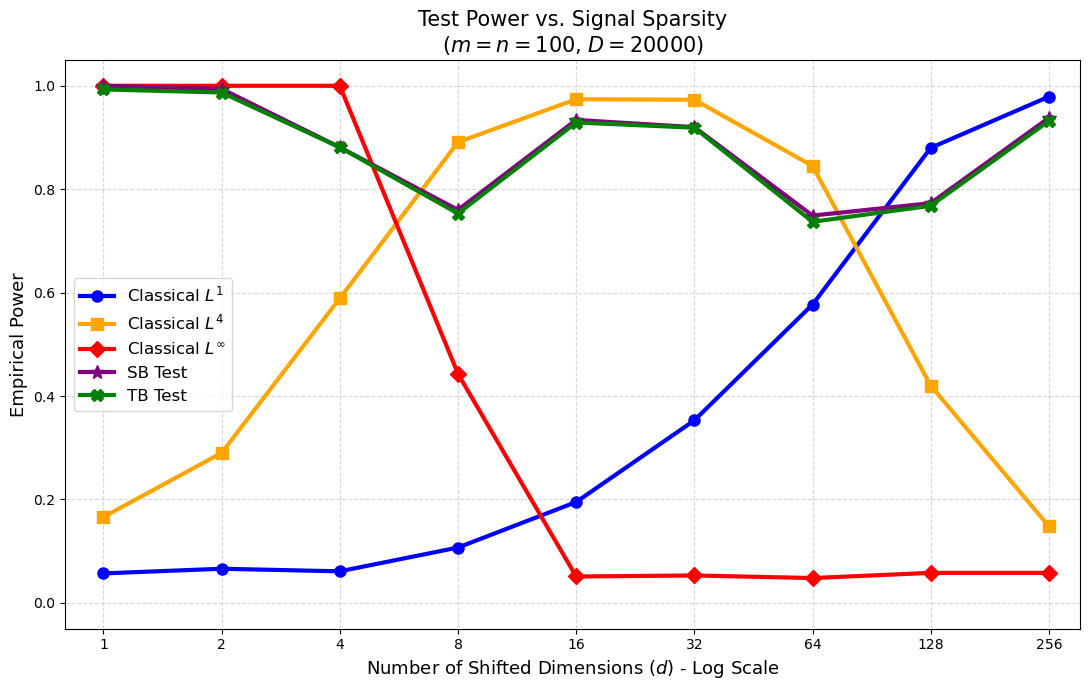

In [7]:
def generate_goldilocks_data(key, m, n, D, d_shifted, shift_val):
    """Generates standard Laplace data with a zero-variance targeted shift."""
    k1, k2 = jax.random.split(key)
    X = jax.random.laplace(k1, shape=(m, D))
    Y = jax.random.laplace(k2, shape=(n, D))
    mask = jnp.arange(D) < d_shifted
    X = jnp.where(mask, shift_val / 2.0, X) 
    Y = jnp.where(mask, -shift_val / 2.0, Y)
    return X, Y

def stat_L1(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=1)

def stat_L4(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=4)

def stat_Linf(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=jnp.inf)

def multi_stats(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.array([jnp.linalg.norm(diff, ord=p) for p in (1, 4, jnp.inf)])

# Jitted for speedups 
@partial(jax.jit, static_argnames=['m', 'n', 'D', 'B', 'alpha'])
def run_single_trial(key, d_shifted, shift_val, m, n, D, B, alpha):
    key_data, key_test = jax.random.split(key)
    X, Y = generate_goldilocks_data(key_data, m, n, D, d_shifted, shift_val)
    data = (X, Y)
    _, out_L1 = classical_permutation_test(key_test, data, stat_L1, B=B, alpha=alpha)
    _, out_L4 = classical_permutation_test(key_test, data, stat_L4, B=B, alpha=alpha)
    _, out_Linf = classical_permutation_test(key_test, data, stat_Linf, B=B, alpha=alpha)
    _, out_SB = sb_test(key_test, data, multi_stats, B=B, alpha=alpha)
    _, out_TB = tb_test(key_test, data, multi_stats, B=B, alpha=alpha)
    return out_L1, out_L4, out_Linf, out_SB, out_TB

def run_experiment():
    m = 100
    n = 100
    D = 20000
    B = 199
    alpha = 0.05
    n_trials = 1000 
    d_values = [1, 2, 4, 8, 16, 32, 64, 128, 256]
    
    print(f"Running Deterministic Goldilocks Subspace Isolation")
    print(f"(m={m}, n={n}, D={D}, B={B}, alpha={alpha})")
    print("-" * 90)
    print(f"{'d_shifted':<10} | {'Shift Val':<10} | {'L1 Power':<10} | {'L4 Power':<10} | {'Linf Power':<10} | {'SB Power':<10} | {'TB Power':<10}")
    print("-" * 90)
    
    master_key = jax.random.PRNGKey(42)
    _ = run_single_trial(master_key, 1, 0.1, m, n, D, B, alpha)  # compiling jitted function
    
    l1_powers = []
    l4_powers = []
    linf_powers = []
    sb_powers = []
    tb_powers = []

    # Computations
    for d in d_values:
        shift_val = 1.1 / (1 + 0.0318 * (d - 1) ** 0.826)
        reject_L1, reject_L4, reject_Linf, reject_SB, reject_TB = 0.0, 0.0, 0.0, 0.0, 0.0 
        for _ in range(n_trials):
            master_key, subkey = jax.random.split(master_key)
            out_L1, out_L4, out_Linf, out_SB, out_TB = run_single_trial(
                subkey, d, shift_val, m, n, D, B, alpha
            )
            reject_L1 += out_L1
            reject_L4 += out_L4
            reject_Linf += out_Linf
            reject_SB += out_SB
            reject_TB += out_TB
            
        p_L1 = reject_L1 / n_trials
        p_L4 = reject_L4 / n_trials
        p_Linf = reject_Linf / n_trials
        p_SB = reject_SB / n_trials
        p_TB = reject_TB / n_trials
        
        l1_powers.append(p_L1)
        l4_powers.append(p_L4)
        linf_powers.append(p_Linf)
        sb_powers.append(p_SB)
        tb_powers.append(p_TB)
        
        print(f"{d:<10} | {shift_val:<10.4f} | {p_L1:<10.2f} | {p_L4:<10.2f} | {p_Linf:<10.2f} | {p_SB:<10.2f} | {p_TB:<10.2f}")
        
    print("-" * 90)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_2a.npz')
    np.savez(save_path, 
             d_values=d_values, 
             l1_powers=l1_powers, 
             l4_powers=l4_powers, 
             linf_powers=linf_powers, 
             sb_powers=sb_powers, 
             tb_powers=tb_powers,
             m=m, 
             D=D)
    print(f"Data successfully saved to {save_path}")
    print("-" * 90)
    
    # Plotting
    plt.figure(figsize=(11, 7))
    plt.plot(d_values, l1_powers, color='blue', marker='o', linewidth=3, markersize=8, label=r'Classical $L^1$')
    plt.plot(d_values, l4_powers, color='orange', marker='s', linewidth=3, markersize=8, label=r'Classical $L^4$')
    plt.plot(d_values, linf_powers, color='red', marker='D', linewidth=3, markersize=8, label=r'Classical $L^\infty$')
    plt.plot(d_values, sb_powers, color='purple', marker='*', linewidth=3, markersize=10, label='SB Test')
    plt.plot(d_values, tb_powers, color='green', marker='X', linewidth=3, markersize=8, label='TB Test')
    
    # Formatting
    plt.xscale('log', base=2)
    plt.xticks(d_values, labels=[str(d) for d in d_values])
    plt.xlim([d_values[0] * 0.8, d_values[-1] * 1.2])
    plt.xlabel('Number of Shifted Dimensions ($d$) - Log Scale', fontsize=13)
    plt.ylabel('Empirical Power', fontsize=13)
    plt.title(f'Test Power vs. Signal Sparsity\n($m=n={m}$, $D={D}$)', fontsize=15)
    plt.ylim([-0.05, 1.05])
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 2b

Running Subspace Isolation vs. Permutation Count (B)
(m=1000, n=1000, D=20000, d=128, Shift Val=0.1000, alpha=0.05)
--------------------------------------------------------------------------------------------------------------
B (Perms)  | L1 Power  | L2 Power  | L3 Power  | SB (Tie)  | TB (Tie)  | SB (NoTie) | TB (NoTie)
--------------------------------------------------------------------------------------------------------------
19         | 0.64      | 0.41      | 0.22      | 0.43      | 0.38      | 0.22       | 0.19      
39         | 0.73      | 0.45      | 0.25      | 0.60      | 0.54      | 0.52       | 0.36      
59         | 0.71      | 0.44      | 0.24      | 0.60      | 0.59      | 0.55       | 0.44      
79         | 0.75      | 0.49      | 0.28      | 0.67      | 0.64      | 0.64       | 0.52      
99         | 0.73      | 0.47      | 0.27      | 0.66      | 0.63      | 0.64       | 0.56      
199        | 0.77      | 0.50      | 0.28      | 0.68      | 0.68      | 0.67   

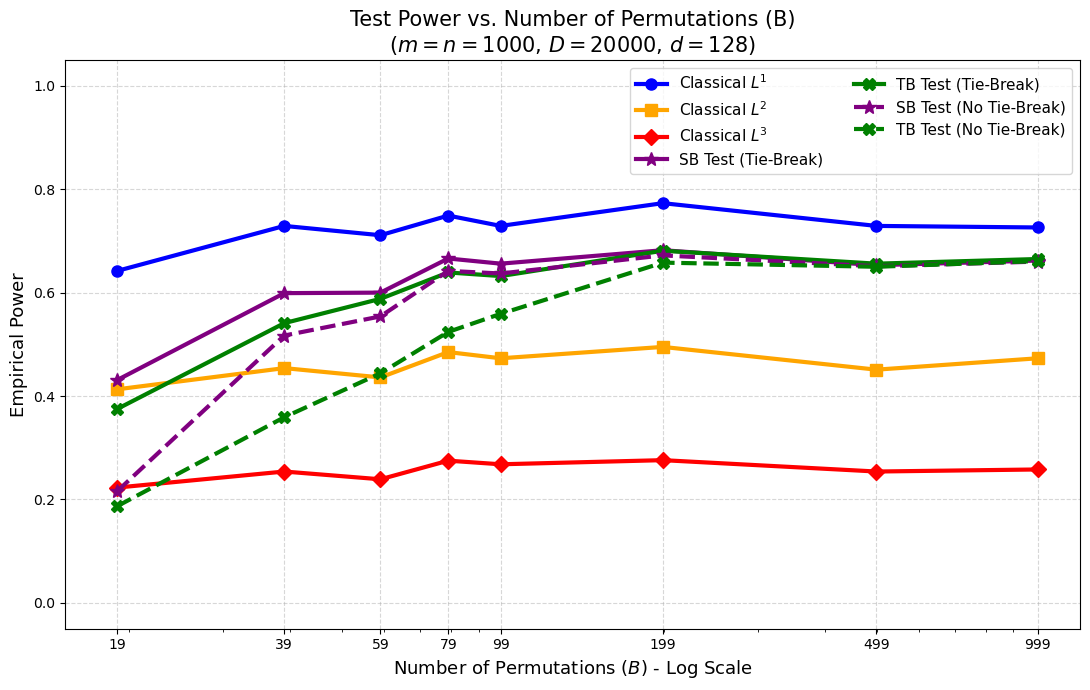

In [8]:
def generate_goldilocks_data(key, m, n, D, d_shifted, shift_val):
    """Generates standard Laplace data with a zero-variance targeted shift."""
    k1, k2 = jax.random.split(key)
    X = jax.random.laplace(k1, shape=(m, D))
    Y = jax.random.laplace(k2, shape=(n, D))
    mask = jnp.arange(D) < d_shifted
    X = jnp.where(mask, shift_val / 2.0, X) 
    Y = jnp.where(mask, -shift_val / 2.0, Y)
    return X, Y

def stat_L1(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=1)

def stat_L2(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=2)

def stat_L3(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.linalg.norm(diff, ord=3)

def multi_stats(data):
    X, Y = data
    diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
    return jnp.array([jnp.linalg.norm(diff, ord=p) for p in (1, 2, 3)])

# Jitted for speedups 
@partial(jax.jit, static_argnames=['m', 'n', 'D', 'B', 'alpha'])
def run_single_trial(key, d_shifted, shift_val, m, n, D, B, alpha):
    key_data, key_test = jax.random.split(key)
    X, Y = generate_goldilocks_data(key_data, m, n, D, d_shifted, shift_val)
    data = (X, Y)
    _, out_L1 = classical_permutation_test(key_test, data, stat_L1, B=B, alpha=alpha, break_ties=True)
    _, out_L2 = classical_permutation_test(key_test, data, stat_L2, B=B, alpha=alpha, break_ties=True)
    _, out_L3 = classical_permutation_test(key_test, data, stat_L3, B=B, alpha=alpha, break_ties=True)

    # Tie Breaking
    _, out_SB_T = sb_test(key_test, data, multi_stats, B=B, alpha=alpha, break_ties=True)
    _, out_TB_T = tb_test(key_test, data, multi_stats, B=B, alpha=alpha, break_ties=True)
    
    # No Tie Breaking
    _, out_SB_F = sb_test(key_test, data, multi_stats, B=B, alpha=alpha, break_ties=False)
    _, out_TB_F = tb_test(key_test, data, multi_stats, B=B, alpha=alpha, break_ties=False)

    return out_L1, out_L2, out_L3, out_SB_T, out_TB_T, out_SB_F, out_TB_F

def run_experiment():
    m = 1000
    n = 1000
    D = 20000
    alpha = 0.05
    n_trials = 1000 
    d_fixed = 128
    shift_val = 0.1
    B_values = [19, 39, 59, 79, 99, 199, 499, 999]
    
    print(f"Running Subspace Isolation vs. Permutation Count (B)")
    print(f"(m={m}, n={n}, D={D}, d={d_fixed}, Shift Val={shift_val:.4f}, alpha={alpha})")
    print("-" * 110)
    print(f"{'B (Perms)':<10} | {'L1 Power':<9} | {'L2 Power':<9} | {'L3 Power':<9} | {'SB (Tie)':<9} | {'TB (Tie)':<9} | {'SB (NoTie)':<10} | {'TB (NoTie)':<10}")
    print("-" * 110)
    
    master_key = jax.random.PRNGKey(42)
    
    l1_powers = []
    l2_powers = []
    l3_powers = []
    sb_t_powers = []
    tb_t_powers = []
    sb_f_powers = []
    tb_f_powers = []

    # Computations
    for B in B_values:
        master_key, subkey = jax.random.split(master_key)
        trial_keys = jax.random.split(subkey, n_trials)
        
        def single_run(k):
            return run_single_trial(k, d_fixed, shift_val, m, n, D, B, alpha)
        
        def scan_step(carry, k):
            return None, single_run(k)
        
        _, (out_L1, out_L2, out_L3, out_SB_T, out_TB_T, out_SB_F, out_TB_F) = jax.lax.scan(scan_step, None, trial_keys)
        
        p_L1 = jnp.mean(out_L1)
        p_L2 = jnp.mean(out_L2)
        p_L3 = jnp.mean(out_L3)
        p_SB_T = jnp.mean(out_SB_T)
        p_TB_T = jnp.mean(out_TB_T)
        p_SB_F = jnp.mean(out_SB_F)
        p_TB_F = jnp.mean(out_TB_F)
        
        l1_powers.append(p_L1)
        l2_powers.append(p_L2)
        l3_powers.append(p_L3)
        sb_t_powers.append(p_SB_T)
        tb_t_powers.append(p_TB_T)
        sb_f_powers.append(p_SB_F)
        tb_f_powers.append(p_TB_F)
        
        print(f"{B:<10} | {p_L1:<9.2f} | {p_L2:<9.2f} | {p_L3:<9.2f} | {p_SB_T:<9.2f} | {p_TB_T:<9.2f} | {p_SB_F:<10.2f} | {p_TB_F:<10.2f}")
        
    print("-" * 110)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_2b.npz')
    np.savez(save_path, 
             B_values=B_values, 
             l1_powers=l1_powers, 
             l2_powers=l2_powers, 
             l3_powers=l3_powers, 
             sb_t_powers=sb_t_powers, 
             tb_t_powers=tb_t_powers,
             sb_f_powers=sb_f_powers,
             tb_f_powers=tb_f_powers,
             m=m, 
             D=D,
             d_fixed=d_fixed)
    print(f"Data successfully saved to {save_path}")
    print("-" * 110)
    
    # Plotting
    plt.figure(figsize=(11, 7))
    plt.plot(B_values, l1_powers, color='blue', marker='o', linewidth=3, markersize=8, label=r'Classical $L^1$')
    plt.plot(B_values, l2_powers, color='orange', marker='s', linewidth=3, markersize=8, label=r'Classical $L^2$')
    plt.plot(B_values, l3_powers, color='red', marker='D', linewidth=3, markersize=8, label=r'Classical $L^3$')
    plt.plot(B_values, sb_t_powers, color='purple', marker='*', linewidth=3, markersize=10, label='SB Test (Tie-Break)')
    plt.plot(B_values, tb_t_powers, color='green', marker='X', linewidth=3, markersize=8, label='TB Test (Tie-Break)')
    plt.plot(B_values, sb_f_powers, color='purple', linestyle='--', marker='*', linewidth=3, markersize=10, label='SB Test (No Tie-Break)')
    plt.plot(B_values, tb_f_powers, color='green', linestyle='--', marker='X', linewidth=3, markersize=8, label='TB Test (No Tie-Break)')
    
    # Formatting
    plt.xscale('log')
    plt.xticks(B_values, labels=[str(b) for b in B_values])
    plt.xlim([B_values[0] * 0.8, B_values[-1] * 1.2])
    plt.xlabel('Number of Permutations ($B$) - Log Scale', fontsize=13)
    plt.ylabel('Empirical Power', fontsize=13)
    plt.title(f'Test Power vs. Number of Permutations (B)\n($m=n={m}$, $D={D}$, $d={d_fixed}$)', fontsize=15)
    plt.ylim([-0.05, 1.05])
    plt.legend(loc='best', fontsize=11, ncol=2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 3a

Running SPARSE Signal Dependency Experiment (Only Dim 1 Shifted)
(n=10000, d=40, B=199, mu_shift=0.03, alpha=0.05)
-----------------------------------------------------------------------------------------------------------------------------
rho (Corr) | Class 1D  | WC Min   SB Min   | WC Med   SB Med   | WC Mean  SB Mean  | DD SB   
-----------------------------------------------------------------------------------------------------------------------------
0.00       | 0.82      | 0.00     0.16     | 0.00     0.07     | 0.00     0.08     | 0.10    
0.10       | 0.84      | 0.00     0.16     | 0.00     0.07     | 0.00     0.08     | 0.12    
0.20       | 0.83      | 0.00     0.19     | 0.00     0.06     | 0.00     0.06     | 0.10    
0.30       | 0.83      | 0.00     0.21     | 0.00     0.05     | 0.00     0.05     | 0.12    
0.40       | 0.86      | 0.00     0.22     | 0.00     0.05     | 0.00     0.05     | 0.12    
0.50       | 0.83      | 0.00     0.25     | 0.00     0.05     | 0.00

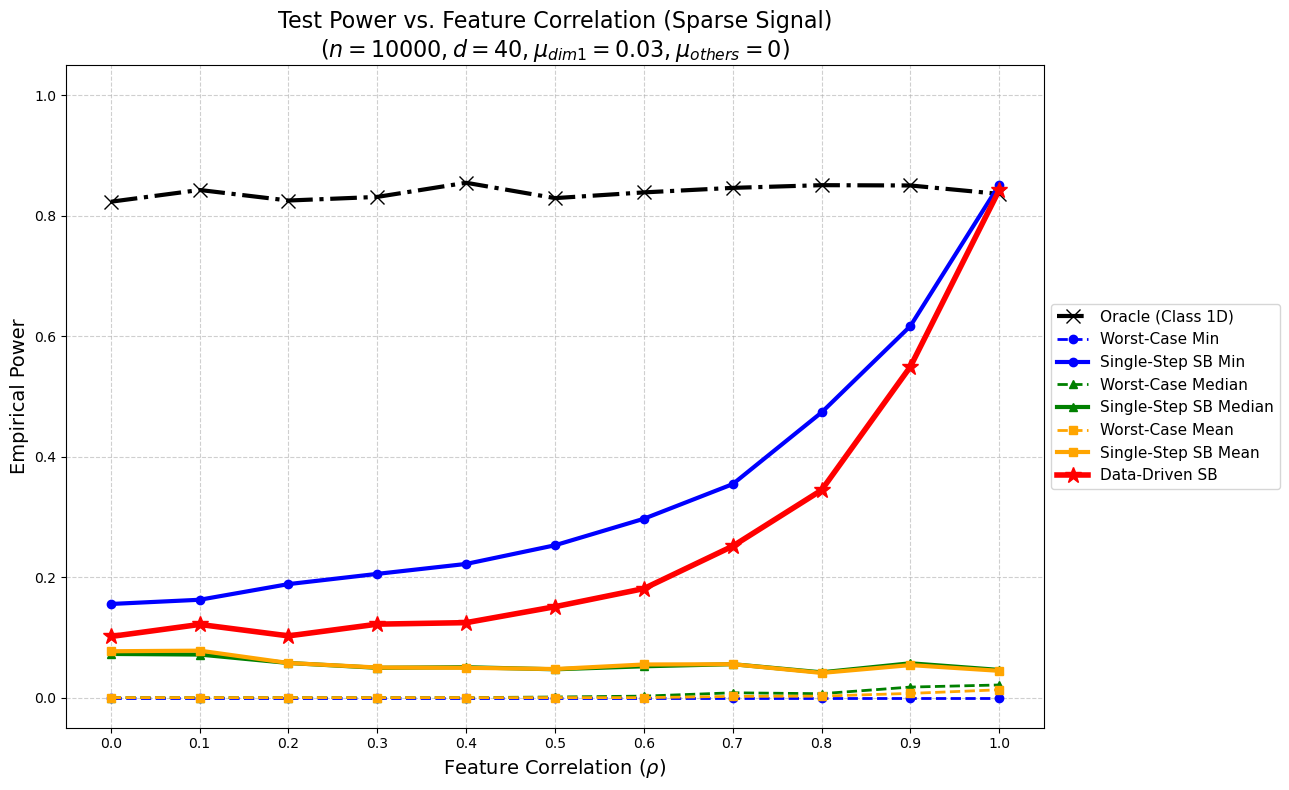

In [9]:
def generate_mvn_data(key, n, d, rho, mu_val):
    """
    Generates n samples from a d-dimensional multivariate normal.
    All dimensions have pairwise correlation rho.
    """
    Sigma = jnp.full((d, d), rho)
    Sigma = jnp.where(jnp.eye(d, dtype=bool), 1.0, Sigma)
    mu = jnp.zeros(d)
    mu = mu.at[0].set(mu_val)
    X = jax.random.multivariate_normal(key, mean=mu, cov=Sigma, shape=(n,), method='eigh')
    return X

def multi_stats(X):
    """
    Returns the d-dimensional absolute one-sample t-statistic vector.
    Absolute value is used to ensure a two-tailed test across all dimensions.
    """
    n = X.shape[0]
    x_bar = jnp.mean(X, axis=0)
    s = jnp.std(X, axis=0, ddof=1)
    s = jnp.where(s == 0, 1e-8, s)
    return jnp.abs(jnp.sqrt(n) * x_bar / s)

def stat_first_dim(X):
    """
    Returns the absolute one-sample t-statistic for ONLY the first dimension.
    This acts as our "Oracle" test since we know the signal is only in dim 0.
    """
    n = X.shape[0]
    x_bar = jnp.mean(X[:, 0])
    s = jnp.std(X[:, 0], ddof=1)
    s = jnp.where(s == 0, 1e-8, s)
    return jnp.abs(jnp.sqrt(n) * x_bar / s)

# Jitted for speedups 
@partial(jax.jit, static_argnames=['n', 'd', 'B', 'alpha'])
def run_single_trial(key, rho, mu_val, n, d, B, alpha):
    k_data, k_test_class, k_test_sb = jax.random.split(key, 3)
    X = generate_mvn_data(k_data, n, d, rho, mu_val)
    _, out_class = classical_permutation_test(
        k_test_class, 
        X, 
        stat_first_dim, 
        framework='one sample test zero', 
        B=B, 
        alpha=alpha, 
        break_ties=True
    )
    p_values_sb = sb_worst_case_tests(
        k_test_sb, 
        X, 
        multi_stats, 
        framework='one sample test zero', 
        B=B, 
        alpha=alpha, 
        break_ties=True
    )
    return out_class, p_values_sb

def run_experiment():
    n = 10000        
    d = 40          
    B = 199         
    mu_val = 0.03   
    alpha = 0.05
    n_trials = 2000 
    rho_values = np.linspace(0, 1.0, 11)
    rho_values[-1] = 0.999999  # Avoid exact 1.0 singularity
    
    print(f"Running SPARSE Signal Dependency Experiment (Only Dim 1 Shifted)")
    print(f"(n={n}, d={d}, B={B}, mu_shift={mu_val}, alpha={alpha})")
    print("-" * 125)
    print(f"{'rho (Corr)':<10} | {'Class 1D':<9} | {'WC Min':<8} {'SB Min':<8} | {'WC Med':<8} {'SB Med':<8} | {'WC Mean':<8} {'SB Mean':<8} | {'DD SB':<8}")
    print("-" * 125)
    
    master_key = jax.random.PRNGKey(42)
    
    res = {
        'class_1d': [],
        'wc_min': [], 'sb_min': [], 
        'wc_med': [], 'sb_med': [], 
        'wc_mean': [], 'sb_mean': [], 
        'dd_sb': []
    }

    # Computations
    for rho in rho_values:
        master_key, subkey_1, subkey_2 = jax.random.split(master_key, 3)
        trial_keys = jax.random.split(subkey_2, n_trials)
        
        def single_run(k):
            return run_single_trial(k, rho, mu_val, n, d, B, alpha)
            
        def scan_step(carry, k):
            return None, single_run(k)
            
        _, (out_class, out_sb_tuple) = jax.lax.scan(scan_step, None, trial_keys)
        
        power_class = jnp.mean(out_class)
        powers_sb = [jnp.mean(p_vals <= alpha) for p_vals in out_sb_tuple]
        
        res['class_1d'].append(power_class)
        res['wc_min'].append(powers_sb[0])
        res['sb_min'].append(powers_sb[1])
        res['wc_med'].append(powers_sb[2])
        res['sb_med'].append(powers_sb[3])
        res['wc_mean'].append(powers_sb[4])
        res['sb_mean'].append(powers_sb[5])
        res['dd_sb'].append(powers_sb[6])
        
        print(f"{rho:<10.2f} | {power_class:<9.2f} | {powers_sb[0]:<8.2f} {powers_sb[1]:<8.2f} | {powers_sb[2]:<8.2f} {powers_sb[3]:<8.2f} | {powers_sb[4]:<8.2f} {powers_sb[5]:<8.2f} | {powers_sb[6]:<8.2f}")
        
    print("-" * 125)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_3a.npz')
    np.savez(save_path, 
             rho_values=rho_values, 
             class_1d=res['class_1d'], 
             wc_min=res['wc_min'], 
             sb_min=res['sb_min'], 
             wc_med=res['wc_med'], 
             sb_med=res['sb_med'], 
             wc_mean=res['wc_mean'], 
             sb_mean=res['sb_mean'],
             dd_sb=res['dd_sb'],
             n=n, 
             d=d,
             mu_val=mu_val)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 125)
    
    # Plotting
    plt.figure(figsize=(13, 8))
    plt.plot(rho_values, res['class_1d'], color='black', linestyle='-.', marker='x', linewidth=3, markersize=10, label='Oracle (Class 1D)')
    plt.plot(rho_values, res['wc_min'], color='blue', linestyle='--', marker='o', linewidth=2, label='Worst-Case Min')
    plt.plot(rho_values, res['sb_min'], color='blue', linestyle='-',  marker='o', linewidth=3, label='Single-Step SB Min')
    plt.plot(rho_values, res['wc_med'], color='green', linestyle='--', marker='^', linewidth=2, label='Worst-Case Median')
    plt.plot(rho_values, res['sb_med'], color='green', linestyle='-',  marker='^', linewidth=3, label='Single-Step SB Median')
    plt.plot(rho_values, res['wc_mean'], color='orange', linestyle='--', marker='s', linewidth=2, label='Worst-Case Mean')
    plt.plot(rho_values, res['sb_mean'], color='orange', linestyle='-',  marker='s', linewidth=3, label='Single-Step SB Mean')
    plt.plot(rho_values, res['dd_sb'], color='red', linestyle='-', marker='*', linewidth=4, markersize=12, label='Data-Driven SB')

    # Formatting
    plt.xlabel('Feature Correlation ($\\rho$)', fontsize=14)
    plt.ylabel('Empirical Power', fontsize=14)
    plt.title(f'Test Power vs. Feature Correlation (Sparse Signal)\n($n={n}, d={d}, \\mu_{{dim1}}={mu_val}, \\mu_{{others}}=0$)', fontsize=16)
    plt.ylim([-0.05, 1.05])
    plt.xticks(rho_values)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 3b

Running Covariance Dependency Experiment (One-Sample t-tests)
(n=10000, d=40, B=199, mu_shift=0.015, alpha=0.05)
-------------------------------------------------------------------------------------------------------------------
rho (Corr) | WC Min   SB Min   | WC Med   SB Med   | WC Mean  SB Mean  | DD SB   
-------------------------------------------------------------------------------------------------------------------
0.00       | 0.00     0.29     | 0.00     1.00     | 0.00     1.00     | 1.00    
0.10       | 0.00     0.27     | 0.02     0.96     | 0.00     0.97     | 0.96    
0.20       | 0.00     0.28     | 0.05     0.85     | 0.00     0.87     | 0.82    
0.30       | 0.00     0.30     | 0.09     0.74     | 0.01     0.75     | 0.69    
0.40       | 0.00     0.27     | 0.10     0.62     | 0.02     0.62     | 0.58    
0.50       | 0.00     0.28     | 0.14     0.53     | 0.04     0.53     | 0.48    
0.60       | 0.00     0.34     | 0.15     0.48     | 0.06     0.48     | 0.45    

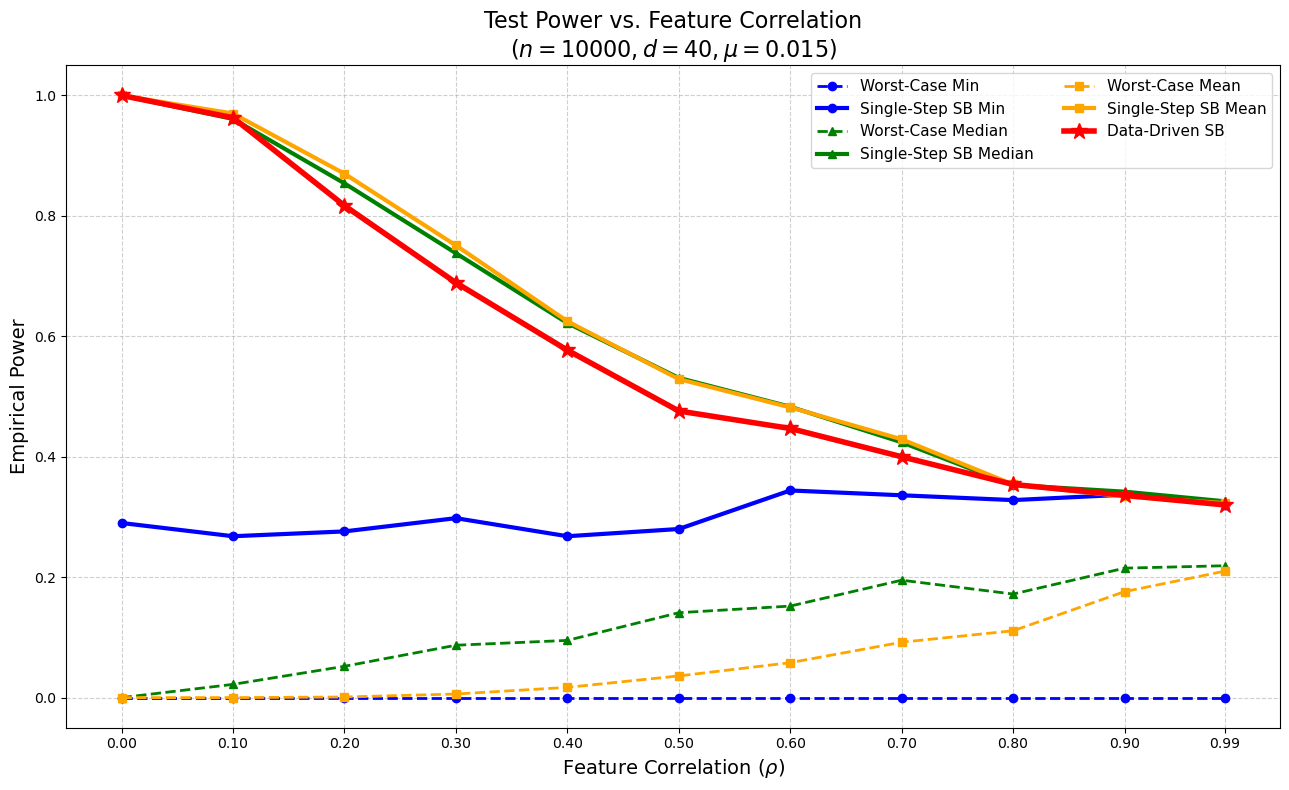

In [10]:
def generate_mvn_data(key, n, d, rho, mu_val):
    """
    Generates n samples from a d-dimensional multivariate normal.
    All dimensions have pairwise correlation rho.
    """
    Sigma = jnp.full((d, d), rho)
    Sigma = jnp.where(jnp.eye(d, dtype=bool), 1.0, Sigma)
    mu = jnp.full((d,), mu_val)
    X = jax.random.multivariate_normal(key, mean=mu, cov=Sigma, shape=(n,), method='eigh')
    return X

def multi_stats(X):
    """
    Returns the d-dimensional absolute one-sample t-statistic vector.
    Absolute value is used to ensure a two-tailed test across all dimensions.
    """
    n = X.shape[0]
    x_bar = jnp.mean(X, axis=0)
    s = jnp.std(X, axis=0, ddof=1)
    s = jnp.where(s == 0, 1e-8, s)
    return jnp.abs(jnp.sqrt(n) * x_bar / s)

# Jitted for speedups 
@partial(jax.jit, static_argnames=['n', 'd', 'B', 'alpha'])
def run_single_trial(key, rho, mu_val, n, d, B, alpha):
    k_data, k_test_sb = jax.random.split(key, 2)
    X = generate_mvn_data(k_data, n, d, rho, mu_val)
    p_values_sb = sb_worst_case_tests(
        k_test_sb, 
        X, 
        multi_stats, 
        framework='one sample test zero', 
        B=B, 
        alpha=alpha, 
        break_ties=True
    )
    return p_values_sb

def run_experiment():
    n = 10000          
    d = 40             
    B = 199             
    mu_val = 0.015       
    alpha = 0.05
    n_trials = 1000         
    rho_values = np.linspace(0, 1.0, 11)
    rho_values[-1] = 0.99
    
    print(f"Running Covariance Dependency Experiment (One-Sample t-tests)")
    print(f"(n={n}, d={d}, B={B}, mu_shift={mu_val}, alpha={alpha})")
    print("-" * 115)
    print(f"{'rho (Corr)':<10} | {'WC Min':<8} {'SB Min':<8} | {'WC Med':<8} {'SB Med':<8} | {'WC Mean':<8} {'SB Mean':<8} | {'DD SB':<8}")
    print("-" * 115)
    
    master_key = jax.random.PRNGKey(42)
    
    res = {
        'wc_min': [], 'sb_min': [], 
        'wc_med': [], 'sb_med': [], 
        'wc_mean': [], 'sb_mean': [], 
        'dd_sb': []
    }

    # Computations
    for rho in rho_values:
        master_key, subkey = jax.random.split(master_key)
        trial_keys = jax.random.split(subkey, n_trials)
        
        def single_run(k):
            return run_single_trial(k, rho, mu_val, n, d, B, alpha)
            
        def scan_step(carry, k):
            return None, single_run(k)
            
        _, out_sb_tuple = jax.lax.scan(scan_step, None, trial_keys)
        powers_sb = [jnp.mean(p_vals <= alpha) for p_vals in out_sb_tuple]
        
        res['wc_min'].append(powers_sb[0])
        res['sb_min'].append(powers_sb[1])
        res['wc_med'].append(powers_sb[2])
        res['sb_med'].append(powers_sb[3])
        res['wc_mean'].append(powers_sb[4])
        res['sb_mean'].append(powers_sb[5])
        res['dd_sb'].append(powers_sb[6])
        
        print(f"{rho:<10.2f} | {powers_sb[0]:<8.2f} {powers_sb[1]:<8.2f} | {powers_sb[2]:<8.2f} {powers_sb[3]:<8.2f} | {powers_sb[4]:<8.2f} {powers_sb[5]:<8.2f} | {powers_sb[6]:<8.2f}")
        
    print("-" * 115)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_3b.npz')
    np.savez(save_path, 
             rho_values=rho_values, 
             wc_min=res['wc_min'], 
             sb_min=res['sb_min'], 
             wc_med=res['wc_med'], 
             sb_med=res['sb_med'], 
             wc_mean=res['wc_mean'], 
             sb_mean=res['sb_mean'],
             dd_sb=res['dd_sb'],
             n=n, 
             d=d,
             mu_val=mu_val)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 115)
    
    # Plotting
    plt.figure(figsize=(13, 8))
    plt.plot(rho_values, res['wc_min'], color='blue', linestyle='--', marker='o', linewidth=2, label='Worst-Case Min')
    plt.plot(rho_values, res['sb_min'], color='blue', linestyle='-',  marker='o', linewidth=3, label='Single-Step SB Min')
    plt.plot(rho_values, res['wc_med'], color='green', linestyle='--', marker='^', linewidth=2, label='Worst-Case Median')
    plt.plot(rho_values, res['sb_med'], color='green', linestyle='-',  marker='^', linewidth=3, label='Single-Step SB Median')
    plt.plot(rho_values, res['wc_mean'], color='orange', linestyle='--', marker='s', linewidth=2, label='Worst-Case Mean')
    plt.plot(rho_values, res['sb_mean'], color='orange', linestyle='-',  marker='s', linewidth=3, label='Single-Step SB Mean')
    plt.plot(rho_values, res['dd_sb'], color='red', linestyle='-', marker='*', linewidth=4, markersize=12, label='Data-Driven SB')

    # Formatting
    plt.xlabel('Feature Correlation ($\\rho$)', fontsize=14)
    plt.ylabel('Empirical Power', fontsize=14)
    plt.title(f'Test Power vs. Feature Correlation\n($n={n}, d={d}, \\mu={mu_val}$)', fontsize=16)
    plt.ylim([-0.05, 1.05])
    plt.xticks(rho_values)
    plt.legend(loc='best', fontsize=11, ncol=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 4a

Running Dirichlet HSIC Independence Experiment (X: $\mathbb{R}^{300}$, Y: $\mathbb{R}^{200}$)
(d=500, c=200, B=39, trials=1000, alpha=0.05)
------------------------------------------------------------------------------------------
n      | SB Min   TB Min   | SB Med   TB Med   | SB Mean  TB Mean  | DD SB    DD TB   
------------------------------------------------------------------------------------------
500    | 0.43     0.49     | 0.02     0.02     | 0.02     0.02     | 0.30     0.32    
1000   | 0.81     0.78     | 0.12     0.12     | 0.07     0.07     | 0.58     0.58    
1500   | 0.88     0.77     | 0.38     0.39     | 0.18     0.18     | 0.69     0.64    
2000   | 0.92     0.78     | 0.74     0.69     | 0.38     0.35     | 0.85     0.71    
2500   | 0.95     0.78     | 0.93     0.83     | 0.58     0.51     | 0.93     0.75    
3000   | 0.97     0.74     | 0.99     0.88     | 0.76     0.66     | 0.98     0.79    
3500   | 0.99     0.79     | 1.00     0.90     | 0.87     0.79     | 

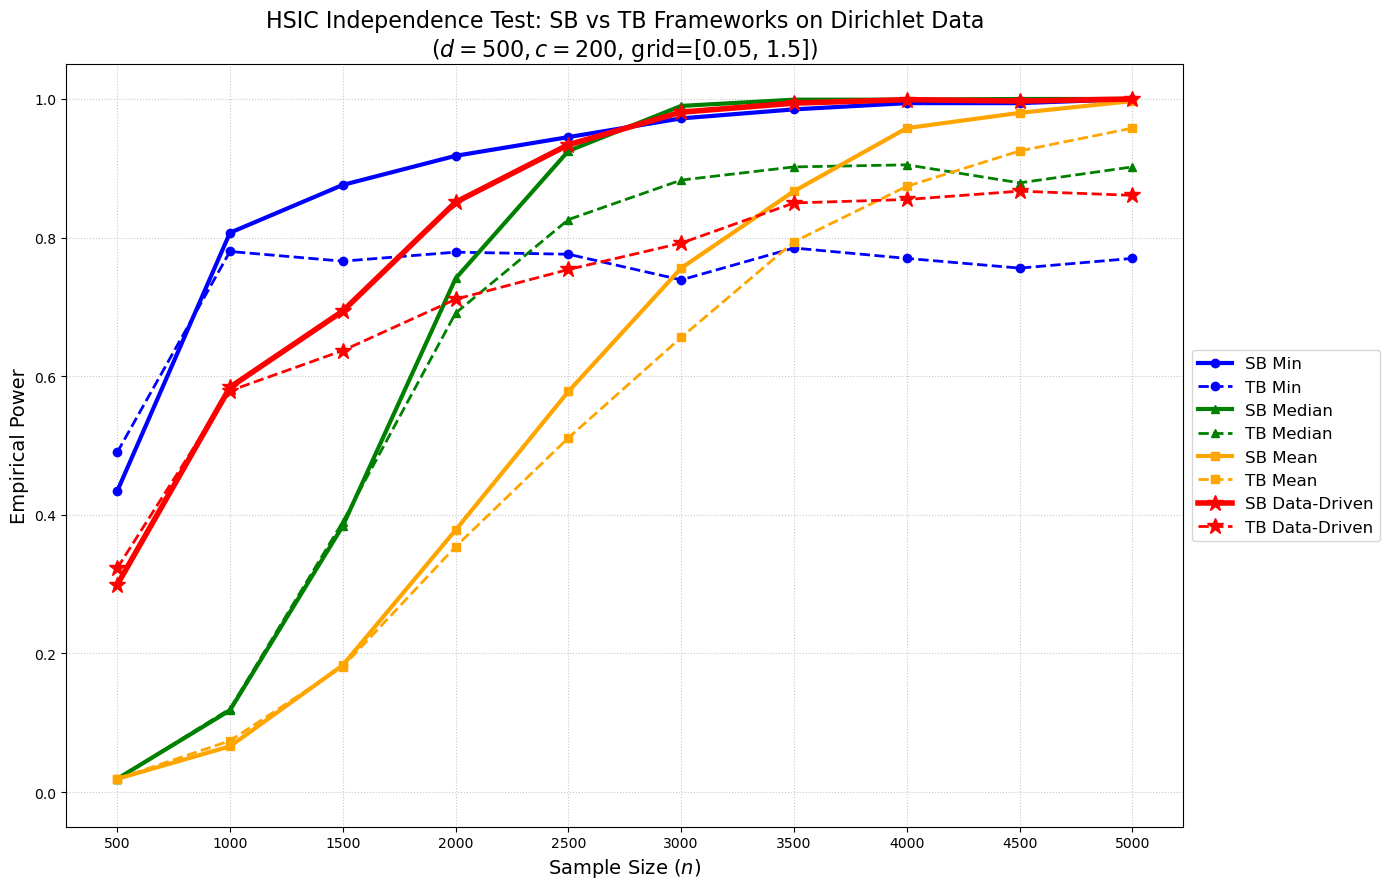

In [11]:
# Jitted for speedups 
@partial(jax.jit, static_argnames=['n', 'd', 'c', 'B', 'alpha_level'])
def run_single_trial(key, n, d, c, B, alpha_level):
    k_data, k_sb, k_tb = jax.random.split(key, 3)
    alpha_vec = jnp.ones(d)
    D_data = jax.random.dirichlet(k_data, alpha_vec, shape=(n,))
    X = D_data[:, :d-c]
    Y = D_data[:, d-c:]
    data = (X, Y)
    num_kernel = 5
    res_sb = hsic_sb_worst_case_tests(
        k_sb, 
        data, 
        bandwidth_min_X=0.05, bandwidth_max_X=1.5, number_bandwidths_X=num_kernel,
        bandwidth_min_Y=0.05, bandwidth_max_Y=1.5, number_bandwidths_Y=num_kernel,
        B=B, 
        alpha=alpha_level, 
        break_ties=True,
        decreasing_collection=True,
    )
    res_tb = hsic_tb_worst_case_tests(
        k_tb, 
        data, 
        bandwidth_min_X=0.05, bandwidth_max_X=1.5, number_bandwidths_X=num_kernel,
        bandwidth_min_Y=0.05, bandwidth_max_Y=1.5, number_bandwidths_Y=num_kernel,
        B=B, 
        alpha=alpha_level, 
        break_ties=True,
        decreasing_collection=True,
    )
    sb_vals = jnp.stack([res_sb[1], res_sb[3], res_sb[5], res_sb[6]])
    tb_vals = jnp.stack([res_tb[1], res_tb[3], res_tb[5], res_tb[6]])
    return sb_vals, tb_vals

def run_experiment():
    d = 500
    c = 200               
    B = 39                
    alpha_level = 0.05
    n_trials = 1000       
    
    n_values = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
    
    print(f"Running Dirichlet HSIC Independence Experiment (X: $\\mathbb{{R}}^{{{d-c}}}$, Y: $\\mathbb{{R}}^{{{c}}}$)")
    print(f"(d={d}, c={c}, B={B}, trials={n_trials}, alpha={alpha_level})")
    print("-" * 90)
    print(f"{'n':<6} | {'SB Min':<8} {'TB Min':<8} | {'SB Med':<8} {'TB Med':<8} | {'SB Mean':<8} {'TB Mean':<8} | {'DD SB':<8} {'DD TB':<8}")
    print("-" * 90)
    
    master_key = jax.random.PRNGKey(42)
    
    res = {
        'sb_min': [], 'sb_med': [], 'sb_mean': [], 'sb_dd': [],
        'tb_min': [], 'tb_med': [], 'tb_mean': [], 'tb_dd': []
    }

    # Computations
    for n in n_values:
        master_key, subkey = jax.random.split(master_key)
        trial_keys = jax.random.split(subkey, n_trials)
        
        def single_run(k):
            return run_single_trial(k, n, d, c, B, alpha_level)
            
        def scan_step(carry, k):
            return None, single_run(k)
            
        _, (sb_matrix, tb_matrix) = jax.lax.scan(scan_step, None, trial_keys)
        
        power_sb = jnp.mean(sb_matrix <= alpha_level, axis=0)
        power_tb = jnp.mean(tb_matrix <= alpha_level, axis=0)
        
        res['sb_min'].append(power_sb[0])
        res['sb_med'].append(power_sb[1])
        res['sb_mean'].append(power_sb[2])
        res['sb_dd'].append(power_sb[3])
        
        res['tb_min'].append(power_tb[0])
        res['tb_med'].append(power_tb[1])
        res['tb_mean'].append(power_tb[2])
        res['tb_dd'].append(power_tb[3])
        
        print(f"{n:<6} | {power_sb[0]:<8.2f} {power_tb[0]:<8.2f} | {power_sb[1]:<8.2f} {power_tb[1]:<8.2f} | {power_sb[2]:<8.2f} {power_tb[2]:<8.2f} | {power_sb[3]:<8.2f} {power_tb[3]:<8.2f}")
        
    print("-" * 90)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_4a.npz')
    np.savez(save_path, 
             n_values=n_values, 
             sb_min=res['sb_min'], 
             sb_med=res['sb_med'], 
             sb_mean=res['sb_mean'], 
             sb_dd=res['sb_dd'],
             tb_min=res['tb_min'], 
             tb_med=res['tb_med'], 
             tb_mean=res['tb_mean'], 
             tb_dd=res['tb_dd'],
             d=d, 
             c=c)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 90)
    
    # Plotting
    plt.figure(figsize=(14, 9))
    plt.plot(n_values, res['sb_min'], color='blue', linestyle='-',  marker='o', linewidth=3, label='SB Min')
    plt.plot(n_values, res['tb_min'], color='blue', linestyle='--', marker='o', linewidth=2, label='TB Min')
    plt.plot(n_values, res['sb_med'], color='green', linestyle='-',  marker='^', linewidth=3, label='SB Median')
    plt.plot(n_values, res['tb_med'], color='green', linestyle='--', marker='^', linewidth=2, label='TB Median')
    plt.plot(n_values, res['sb_mean'], color='orange', linestyle='-',  marker='s', linewidth=3, label='SB Mean')
    plt.plot(n_values, res['tb_mean'], color='orange', linestyle='--', marker='s', linewidth=2, label='TB Mean')
    plt.plot(n_values, res['sb_dd'], color='red', linestyle='-',  marker='*', linewidth=4, markersize=12, label='SB Data-Driven')
    plt.plot(n_values, res['tb_dd'], color='red', linestyle='--', marker='*', linewidth=2, markersize=12, label='TB Data-Driven')

    # Formatting
    plt.xlabel('Sample Size ($n$)', fontsize=14)
    plt.ylabel('Empirical Power', fontsize=14)
    plt.title(f'HSIC Independence Test: SB vs TB Frameworks on Dirichlet Data\n($d={d}, c={c}$, grid=[{0.05}, {1.5}])', fontsize=16)
    plt.ylim([-0.05, 1.05])
    plt.xticks(n_values)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 4b

Running HSIC Bandwidth Grid Experiment (Dirichlet Data)
(n=500, d=200, c=80, B=199, trials=1000, alpha=0.05)
--------------------------------------------------------------------------------------------------------------
K    | Total  | WC Min SB Min | WC Med SB Med | WC Mean SB Mean | DD SB 
--------------------------------------------------------------------------------------------------------------
1    | 1      | 0.05   0.05   | 0.03   0.05   | 0.03    0.05    | 0.05  
2    | 4      | 0.05   0.15   | 0.04   0.09   | 0.04    0.08    | 0.14  
3    | 9      | 0.45   0.76   | 0.13   0.21   | 0.08    0.17    | 0.74  
4    | 16     | 0.00   1.00   | 0.36   0.51   | 0.11    0.30    | 1.00  
5    | 25     | 0.00   1.00   | 0.76   0.87   | 0.16    0.51    | 1.00  
6    | 36     | 0.00   1.00   | 0.92   0.99   | 0.20    0.80    | 0.99  
7    | 49     | 0.00   0.95   | 0.74   0.97   | 0.01    0.89    | 0.95  
8    | 64     | 0.00   0.69   | 0.28   0.95   | 0.00    0.88    | 0.91  
9    | 81   

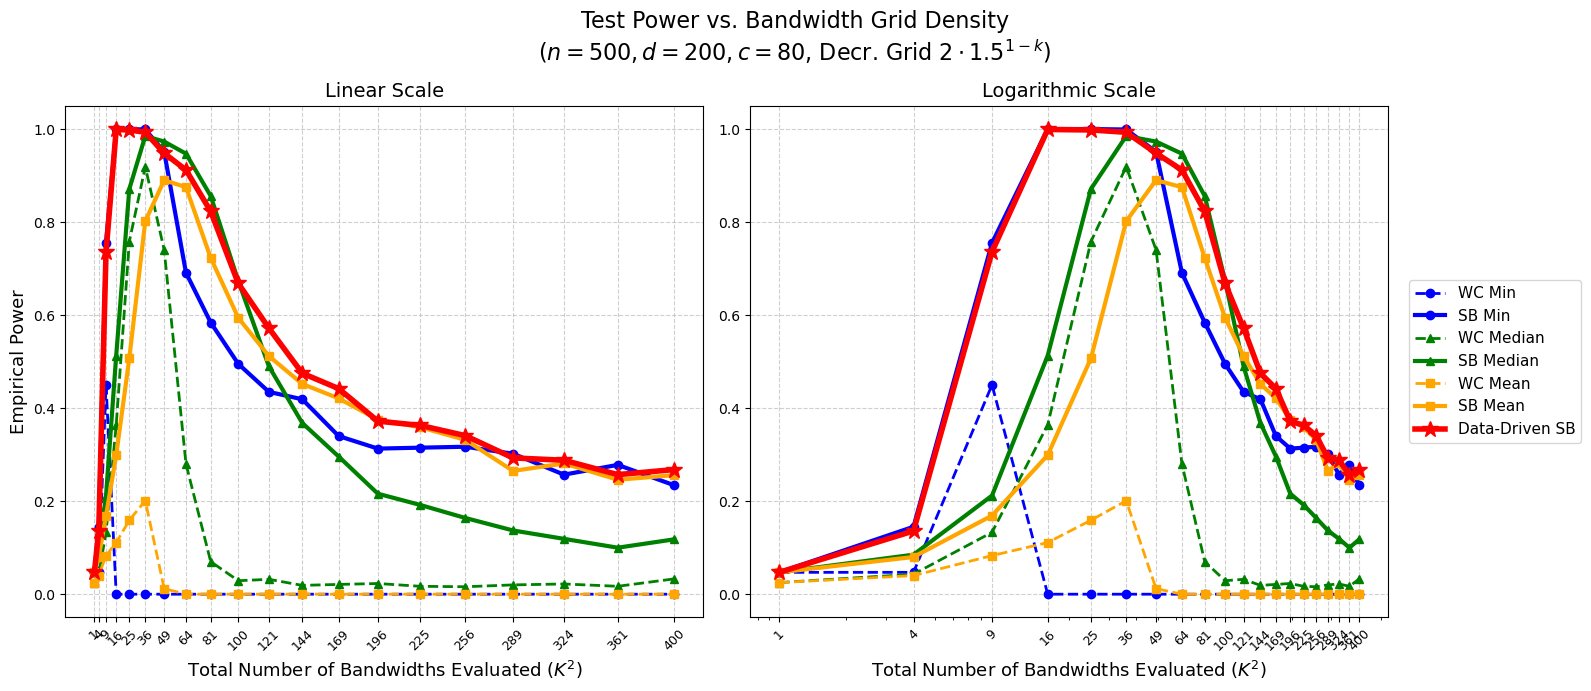

In [12]:
# Jitted for speedups 
@partial(jax.jit, static_argnames=['n', 'd', 'c', 'B', 'alpha_level', 'K'])
def run_single_trial(key, n, d, c, B, alpha_level, K):
    k_data, k_sb = jax.random.split(key, 2)
    alpha_vec = jnp.ones(d)
    D_data = jax.random.dirichlet(k_data, alpha_vec, shape=(n,))
    X = D_data[:, :d-c]
    Y = D_data[:, d-c:]
    data = (X, Y)
    res_sb = hsic_sb_worst_case_tests(
        k_sb, 
        data, 
        bandwidth_min_X=0.05, bandwidth_max_X=1.5, number_bandwidths_X=K,
        bandwidth_min_Y=0.05, bandwidth_max_Y=1.5, number_bandwidths_Y=K,
        B=B, 
        alpha=alpha_level, 
        break_ties=True,
        decreasing_collection=True,
        s=1.5
    )
    sb_vals = jnp.stack(res_sb)
    return sb_vals

def run_experiment():
    n = 500                
    d = 200
    c = 80                 
    B = 199                
    alpha_level = 0.05
    n_trials = 1000 
    K_values = np.arange(1, 21)
    
    print(f"Running HSIC Bandwidth Grid Experiment (Dirichlet Data)")
    print(f"(n={n}, d={d}, c={c}, B={B}, trials={n_trials}, alpha={alpha_level})")
    print("-" * 110)
    print(f"{'K':<4} | {'Total':<6} | {'WC Min':<6} {'SB Min':<6} | {'WC Med':<6} {'SB Med':<6} | {'WC Mean':<7} {'SB Mean':<7} | {'DD SB':<6}")
    print("-" * 110)
    
    master_key = jax.random.PRNGKey(42)
    
    res = {
        'wc_min': [], 'sb_min': [], 
        'wc_med': [], 'sb_med': [], 
        'wc_mean': [], 'sb_mean': [], 
        'sb_dd': []
    }

    # Computations
    for K in K_values:
        master_key, subkey = jax.random.split(master_key)
        trial_keys = jax.random.split(subkey, n_trials)
        
        def single_run(k):
            return run_single_trial(k, n, d, c, B, alpha_level, int(K))
            
        def scan_step(carry, k):
            return None, single_run(k)
            
        _, sb_matrix = jax.lax.scan(scan_step, None, trial_keys)
        
        power_sb = jnp.mean(sb_matrix <= alpha_level, axis=0)
        
        res['wc_min'].append(power_sb[0])
        res['sb_min'].append(power_sb[1])
        res['wc_med'].append(power_sb[2])
        res['sb_med'].append(power_sb[3])
        res['wc_mean'].append(power_sb[4])
        res['sb_mean'].append(power_sb[5])
        res['sb_dd'].append(power_sb[6])
        
        print(f"{K:<4} | {K**2:<6} | {power_sb[0]:<6.2f} {power_sb[1]:<6.2f} | {power_sb[2]:<6.2f} {power_sb[3]:<6.2f} | {power_sb[4]:<7.2f} {power_sb[5]:<7.2f} | {power_sb[6]:<6.2f}")
        
    print("-" * 110)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_4b.npz')
    np.savez(save_path, 
             K_values=K_values, 
             wc_min=res['wc_min'], 
             sb_min=res['sb_min'], 
             wc_med=res['wc_med'], 
             sb_med=res['sb_med'], 
             wc_mean=res['wc_mean'], 
             sb_mean=res['sb_mean'],
             sb_dd=res['sb_dd'],
             n=n, 
             d=d, 
             c=c)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 110)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    total_bandwidths = [k**2 for k in K_values]
    
    # Plot 1
    ax1.plot(total_bandwidths, res['wc_min'], color='blue',   linestyle='--', marker='o', linewidth=2, label='WC Min')
    ax1.plot(total_bandwidths, res['sb_min'], color='blue',   linestyle='-',  marker='o', linewidth=3, label='SB Min')
    ax1.plot(total_bandwidths, res['wc_med'], color='green',  linestyle='--', marker='^', linewidth=2, label='WC Median')
    ax1.plot(total_bandwidths, res['sb_med'], color='green',  linestyle='-',  marker='^', linewidth=3, label='SB Median')
    ax1.plot(total_bandwidths, res['wc_mean'], color='orange', linestyle='--', marker='s', linewidth=2, label='WC Mean')
    ax1.plot(total_bandwidths, res['sb_mean'], color='orange', linestyle='-',  marker='s', linewidth=3, label='SB Mean')
    ax1.plot(total_bandwidths, res['sb_dd'],   color='red',    linestyle='-',  marker='*', linewidth=4, markersize=12, label='Data-Driven SB')
    ax1.set_xlabel('Total Number of Bandwidths Evaluated ($K^2$)', fontsize=13)
    ax1.set_ylabel('Empirical Power', fontsize=13)
    ax1.set_title('Linear Scale', fontsize=14)
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_xticks(total_bandwidths)
    ax1.tick_params(axis='x', rotation=45, labelsize=9)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot 2
    ax2.plot(total_bandwidths, res['wc_min'], color='blue',   linestyle='--', marker='o', linewidth=2)
    ax2.plot(total_bandwidths, res['sb_min'], color='blue',   linestyle='-',  marker='o', linewidth=3)
    ax2.plot(total_bandwidths, res['wc_med'], color='green',  linestyle='--', marker='^', linewidth=2)
    ax2.plot(total_bandwidths, res['sb_med'], color='green',  linestyle='-',  marker='^', linewidth=3)
    ax2.plot(total_bandwidths, res['wc_mean'], color='orange', linestyle='--', marker='s', linewidth=2)
    ax2.plot(total_bandwidths, res['sb_mean'], color='orange', linestyle='-',  marker='s', linewidth=3)
    ax2.plot(total_bandwidths, res['sb_dd'],   color='red',    linestyle='-',  marker='*', linewidth=4, markersize=12)
    ax2.set_xscale('log')
    ax2.set_xlabel('Total Number of Bandwidths Evaluated ($K^2$)', fontsize=13)
    ax2.set_title('Logarithmic Scale', fontsize=14)
    ax2.set_ylim([-0.05, 1.05])
    ax2.set_xticks(total_bandwidths)
    ax2.set_xticklabels(total_bandwidths, rotation=45, fontsize=9)
    ax2.grid(True, linestyle='--', alpha=0.6)
    plt.suptitle(f'Test Power vs. Bandwidth Grid Density\n($n={n}, d={d}, c={c}$, Decr. Grid $2 \\cdot 1.5^{{1-k}}$)', fontsize=16)
    ax2.legend(handles=ax1.lines, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 5a

Running Empirical Level Experiment (H0 is True)
(n=50, d=5, B=10, K=2, trials=20000)
Evaluating dense alpha grid...
Data successfully saved to results/experiment_5a.npz
--------------------------------------------------


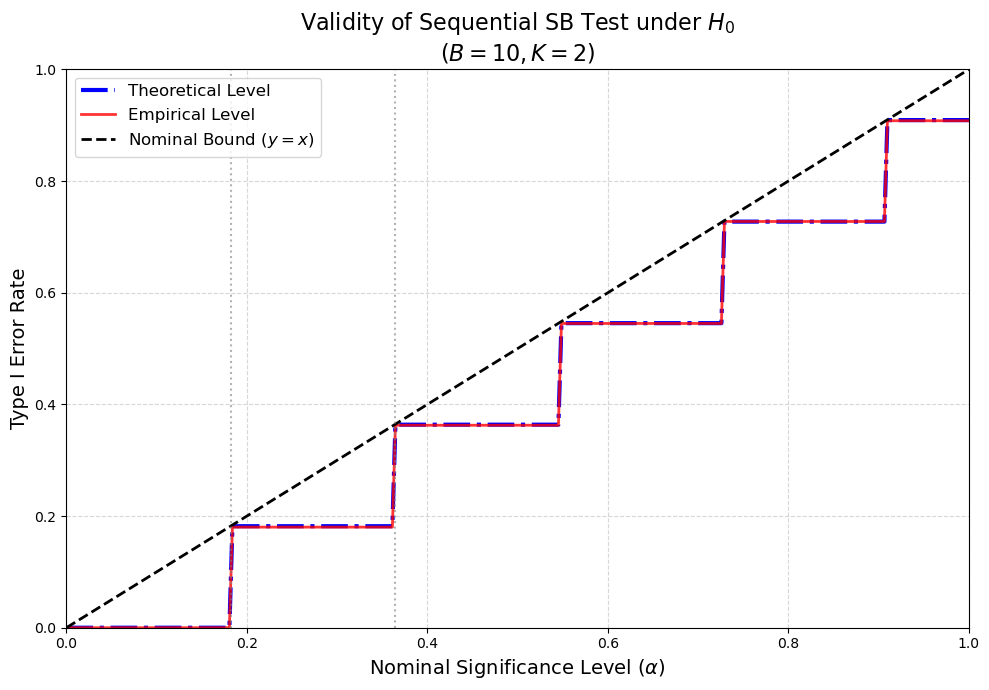

In [13]:
# Jitted for speedups 
@partial(jax.jit, static_argnames=['n', 'd', 'B', 'K'])
def run_single_trial(key, n, d, B, K, alpha_array):
    k_data, k_perm, k_test = jax.random.split(key, 3)
    Z = jax.random.uniform(k_data, shape=(2*n, d))
    keys_perm = jax.random.split(k_perm, B + 1)
    idx = jax.vmap(jax.random.permutation, in_axes=(0, None))(keys_perm, jnp.arange(2*n))
    idx = idx.at[0].set(jnp.arange(2*n))
    
    def compute_stat(indices):
        Z_perm = Z[indices]
        X = Z_perm[:n]
        Y = Z_perm[n:]
        diff = jnp.mean(X, axis=0) - jnp.mean(Y, axis=0)
        abs_diff = jnp.abs(diff)
        p_vals = jnp.arange(1, K + 1)
        norms = jnp.sum(abs_diff[None, :] ** p_vals[:, None], axis=1) ** (1.0 / p_vals)
        return norms
        
    stats_matrix = jax.lax.map(compute_stat, idx)
    
    def test_alpha(alpha):
        rejected, _ = seq_sb_test(stats_matrix, alpha=alpha, key=k_test)
        return rejected
        
    return jax.vmap(test_alpha)(alpha_array)

def run_experiment():
    n = 50              
    d = 5               
    B = 10              
    K = 2               
    n_trials = 20000    
    alpha_values = jnp.linspace(0.00, 1, 300)
    
    print(f"Running Empirical Level Experiment (H0 is True)")
    print(f"(n={n}, d={d}, B={B}, K={K}, trials={n_trials})")
    print("Evaluating dense alpha grid...")
    
    master_key = jax.random.PRNGKey(42)
    master_key, subkey = jax.random.split(master_key)
    trial_keys = jax.random.split(subkey, n_trials)
    
    def scan_step(carry, k):
        reject_array = run_single_trial(k, n, d, B, K, alpha_values)
        return None, reject_array

    # Computations 
    _, reject_matrix = jax.lax.scan(scan_step, None, trial_keys)
    empirical_levels = jnp.mean(reject_matrix, axis=0)
    theoretical_levels = (K / (B + 1.0)) * jnp.floor(alpha_values * (B + 1.0) / K)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_5a.npz')
    np.savez(save_path, 
             alpha_values=alpha_values, 
             empirical_levels=empirical_levels, 
             theoretical_levels=theoretical_levels,
             n=n, 
             d=d, 
             B=B, 
             K=K)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 50)
    
    # Plotting
    plt.figure(figsize=(10, 7))
    plt.plot(alpha_values, theoretical_levels, color='blue', linestyle='-.', linewidth=3, label='Theoretical Level')
    plt.plot(alpha_values, empirical_levels, color='red', linewidth=2, alpha=0.8, label='Empirical Level')
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2, label='Nominal Bound ($y=x$)')
    step_alphas = [k * K / (B + 1) for k in range(1, int(0.5 * (B + 1) / K) + 1)]
    for step_alpha in step_alphas:
        plt.axvline(x=step_alpha, color='gray', linestyle=':', alpha=0.6)
    
    # Formatting
    plt.xlabel('Nominal Significance Level ($\\alpha$)', fontsize=14)
    plt.ylabel('Type I Error Rate', fontsize=14)
    plt.title(f'Validity of Sequential SB Test under $H_0$\n($B={B}, K={K}$)', fontsize=16)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 5b

-----------------------------------------------------------------
Running Empirical Power Sequential Experiment
n=1000, d=50, K=10, B=199, trials=1000
sigma=1.035 -> Bandwidth=57.4105
-----------------------------------------------------------------
Executing dense epsilon grid (Wait for JIT Compilation)...
Data successfully saved to results/experiment_5b.npz
-----------------------------------------------------------------


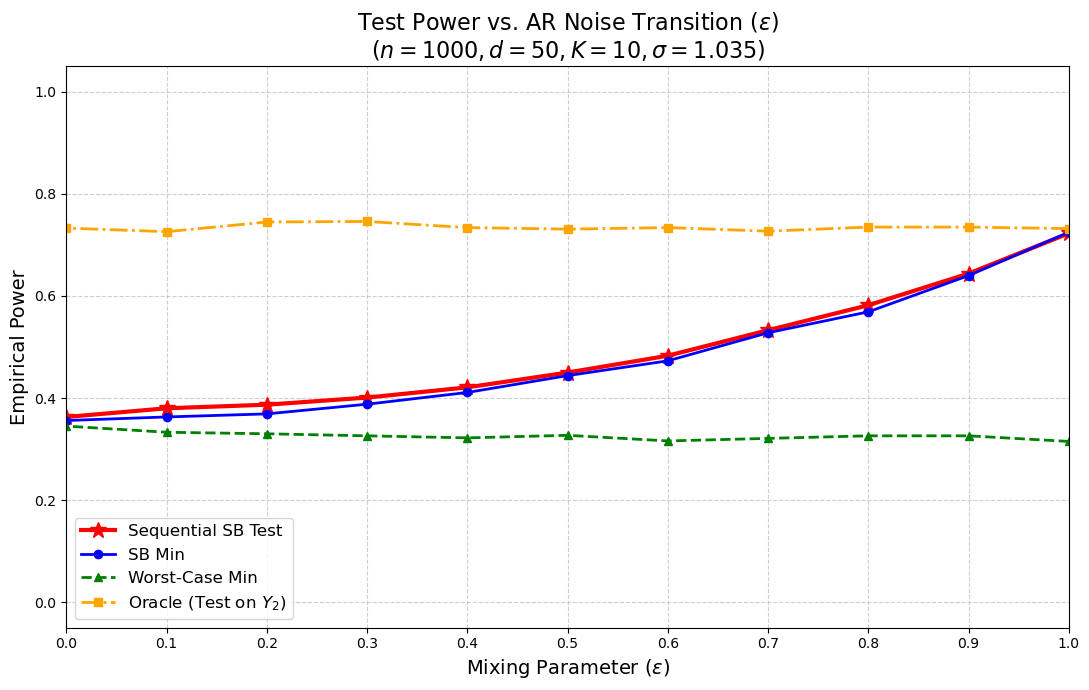

In [14]:
def run_experiment():
    n = 1000
    d = 50
    K = 10
    B = 199
    alpha = 0.05
    sigma = 1.035
    n_trials = 1000  
    bandwidth = (d / (2.0 * jnp.sqrt(jnp.pi))) * (1.0 + sigma + jnp.sqrt(2.0 * (1.0 + sigma ** 2)))  # chosen for laplace kernel
    eps_values = jnp.linspace(0.0, 1.0, 11)
    
    print("-" * 65)
    print("Running Empirical Power Sequential Experiment")
    print(f"n={n}, d={d}, K={K}, B={B}, trials={n_trials}")
    print(f"sigma={sigma} -> Bandwidth={bandwidth:.4f}")
    print("-" * 65)
    print("Executing dense epsilon grid (Wait for JIT Compilation)...")
    
    master_key = jax.random.PRNGKey(42)
    master_key, subkey = jax.random.split(master_key)
    trial_keys = jax.random.split(subkey, n_trials)

    # Computations
    # Jitted for speedups 
    @jax.jit
    def eval_all_eps(k_trial):
        # use same randomness on purpose
        
        def single_eps(eps):
            rej_seq, p_sb, p_wc, p_oracle = all_seq_test(
                k_trial, n, d, eps, sigma, K, B, bandwidth, alpha, break_ties=True
            )
            return jnp.array([
                rej_seq,           
                p_sb <= alpha,     
                p_wc <= alpha,     
                p_oracle <= alpha  
            ]) 
            
        return jax.vmap(single_eps)(eps_values)

    def scan_step(carry, k):
        return None, eval_all_eps(k)

    _, results_matrix = jax.lax.scan(scan_step, None, trial_keys)
    empirical_power = jnp.mean(results_matrix, axis=0)
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_5b.npz')
    np.savez(save_path, 
             eps_values=eps_values, 
             empirical_power=empirical_power,
             n=n, 
             d=d, 
             K=K, 
             B=B, 
             sigma=sigma,
             bandwidth=bandwidth)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 65)
    
    # Plotting
    plt.figure(figsize=(11, 7))
    
    plt.plot(1-eps_values, empirical_power[:, 0], label='Sequential SB Test', color='red', marker='*', linewidth=3, markersize=12)
    plt.plot(1-eps_values, empirical_power[:, 1], label='SB Min', color='blue', marker='o', linewidth=2)
    plt.plot(1-eps_values, empirical_power[:, 2], label='Worst-Case Min', color='green', marker='^', linestyle='--', linewidth=2)
    plt.plot(1-eps_values, empirical_power[:, 3], label='Oracle (Test on $Y_2$)', color='orange', marker='s', linestyle='-.', linewidth=2)
    
    # Formatting
    plt.xlabel(r'Mixing Parameter ($\epsilon$)', fontsize=14)
    plt.ylabel('Empirical Power', fontsize=14)
    plt.title(fr'Test Power vs. AR Noise Transition ($\epsilon$)' + '\n' + fr'($n={n}, d={d}, K={K}, \sigma={sigma}$)', fontsize=16)
    plt.xlim([0.0, 1.0])
    plt.ylim([-0.05, 1.05])
    plt.xticks(eps_values)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower left', fontsize=12)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 5c

-----------------------------------------------------------------
Running Sequential Decision Stage Experiment
n=1000, d=50, K=10, B=199, trials=1000
epsilon=0.1, sigma in [1.00, 1.05]
-----------------------------------------------------------------
Executing dense sigma grid (Wait for JIT Compilation)...
Data successfully saved to results/experiment_5c.npz
-----------------------------------------------------------------


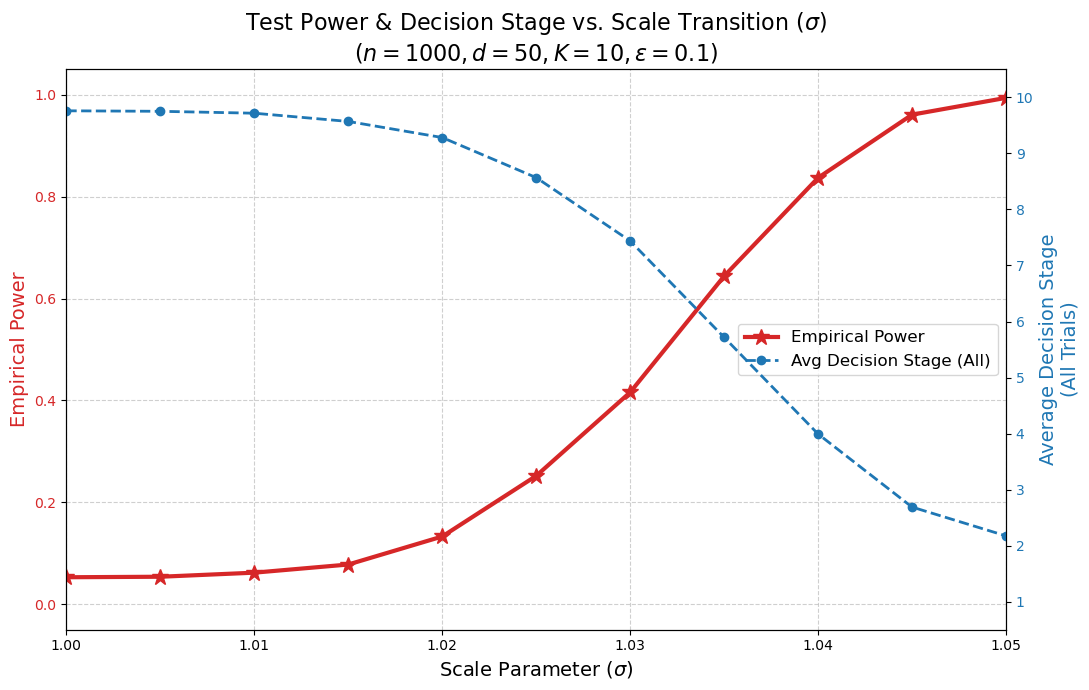

In [15]:
def run_experiment():
    n = 1000
    d = 50
    K = 10
    B = 199
    alpha = 0.05
    epsilon = 0.1
    n_trials = 1000 
    include_fail_to_reject = True 
    sigma_num = 11
    sigma_min = 1.0
    sigma_max = 1.05
    sigma_values = jnp.linspace(sigma_min, sigma_max, sigma_num)
    
    print("-" * 65)
    print("Running Sequential Decision Stage Experiment")
    print(f"n={n}, d={d}, K={K}, B={B}, trials={n_trials}")
    print(f"epsilon={epsilon}, sigma in [{sigma_values[0]:.2f}, {sigma_values[-1]:.2f}]")
    print("-" * 65)
    print("Executing dense sigma grid (Wait for JIT Compilation)...")
    
    master_key = jax.random.PRNGKey(42)
    master_key, subkey = jax.random.split(master_key)
    trial_keys = jax.random.split(subkey, n_trials)

    # Computations
    # Jitted for speedups 
    @jax.jit
    def eval_all_sigmas(k_trial):
        # Split key once per trial so the same baseline noise is used across all sigmas
        k_gen, k_seq = jax.random.split(k_trial, 2)
        
        def single_sigma(sigma):
            bandwidth = (d / (2.0 * jnp.sqrt(jnp.pi))) * (1.0 + sigma + jnp.sqrt(2.0 * (1.0 + sigma ** 2)))
            stats_matrix = generate_seq_data_matrix(k_gen, n, d, epsilon, sigma, K, B, bandwidth)
            rej_seq, dec_stage = seq_sb_test(stats_matrix, alpha=alpha, key=k_seq)
            return jnp.array([rej_seq, dec_stage])
            
        return jax.vmap(single_sigma)(sigma_values)

    def scan_step(carry, k):
        return None, eval_all_sigmas(k)

    # Power
    _, results_matrix = jax.lax.scan(scan_step, None, trial_keys)
    rej_matrix = np.array(results_matrix[:, :, 0])
    stage_matrix = np.array(results_matrix[:, :, 1])
    empirical_power = np.mean(rej_matrix, axis=0)
    
    # Average Decision Stage
    if include_fail_to_reject:
        avg_stage = np.mean(stage_matrix, axis=0)
        std_stage = np.std(stage_matrix, axis=0)
        stage_ylabel = 'Average Decision Stage\n(All Trials)'
        stage_label = 'Avg Decision Stage (All)'
    else:
        stage_matrix_masked = np.where(rej_matrix == 1, stage_matrix, np.nan)
        
        with warnings.catch_warnings(): 
            warnings.simplefilter("ignore", category=RuntimeWarning)
            avg_stage = np.nanmean(stage_matrix_masked, axis=0)
            std_stage = np.nanstd(stage_matrix_masked, axis=0)
            
        stage_ylabel = 'Average Decision Stage\n(Conditioned on Rejection)'
        stage_label = 'Avg Decision Stage (Rejections)'
    
    # Create the 'results' directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    # Save the arrays and required metadata to an .npz file
    save_path = os.path.join('results', 'experiment_5c.npz')
    np.savez(save_path, 
             sigma_values=sigma_values, 
             empirical_power=empirical_power,
             avg_stage=avg_stage,
             std_stage=std_stage,
             n=n, 
             d=d, 
             K=K, 
             epsilon=epsilon,
             include_fail_to_reject=include_fail_to_reject)
    
    print(f"Data successfully saved to {save_path}")
    print("-" * 65)
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(11, 7))
    
    # Left Axis: Empirical Power
    color1 = 'tab:red'
    ax1.set_xlabel(r'Scale Parameter ($\sigma$)', fontsize=14)
    ax1.set_ylabel('Empirical Power', color=color1, fontsize=14)
    line1 = ax1.plot(sigma_values, empirical_power, color=color1, marker='*', linewidth=3, markersize=12, label='Empirical Power')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xlim([sigma_min, sigma_max])
    ax1.set_ylim([-0.05, 1.05])
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Right Axis: Average Decision Stage
    ax2 = ax1.twinx()
    color2 = 'tab:blue'
    ax2.set_ylabel(stage_ylabel, color=color2, fontsize=14)
    line2 = ax2.plot(sigma_values, avg_stage, color=color2, marker='o', linestyle='--', linewidth=2, label=stage_label)    
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim([0.5, K + 0.5])
    ax2.set_yticks(np.arange(1, K + 1))
    
    # Formatting
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', fontsize=12)
    plt.title(fr'Test Power & Decision Stage vs. Scale Transition ($\sigma$)' + '\n' + fr'($n={n}, d={d}, K={K}, \epsilon={epsilon}$)', fontsize=16)
    fig.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 6a

Running Exact Conformal
n_calib=999, n_1=500, n_test=100, K=20, alpha=0.1
Trials=1000 -> Total Evaluated Test Points=100000
Running experiment for 'min'...
Running experiment for 'avg'...
Running experiment for 'median'...

EXPERIMENT RESULTS: EXACT MARGINAL COVERAGE (Target > 0.90)
Agg Func   | SB (Exact)   | SB Worst-Case   | TB (Exact)   | TB Worst-Case  
--------------------------------------------------------------------------------
Min        | 0.8962       | 0.9893          | 0.8995       | 0.9917         
Avg        | 0.8975       | 0.9726          | 0.8973       | 0.9732         
Median     | 0.8980       | 0.9495          | 0.8988       | 0.9499         

--------------------------------------------------------------------------------
EXPERIMENT RESULTS: EXACT PREDICTION SET SIZE
--------------------------------------------------------------------------------
Agg Func   | SB (Exact)   | SB Worst-Case   | TB (Exact)   | TB Worst-Case  
-----------------------------------------

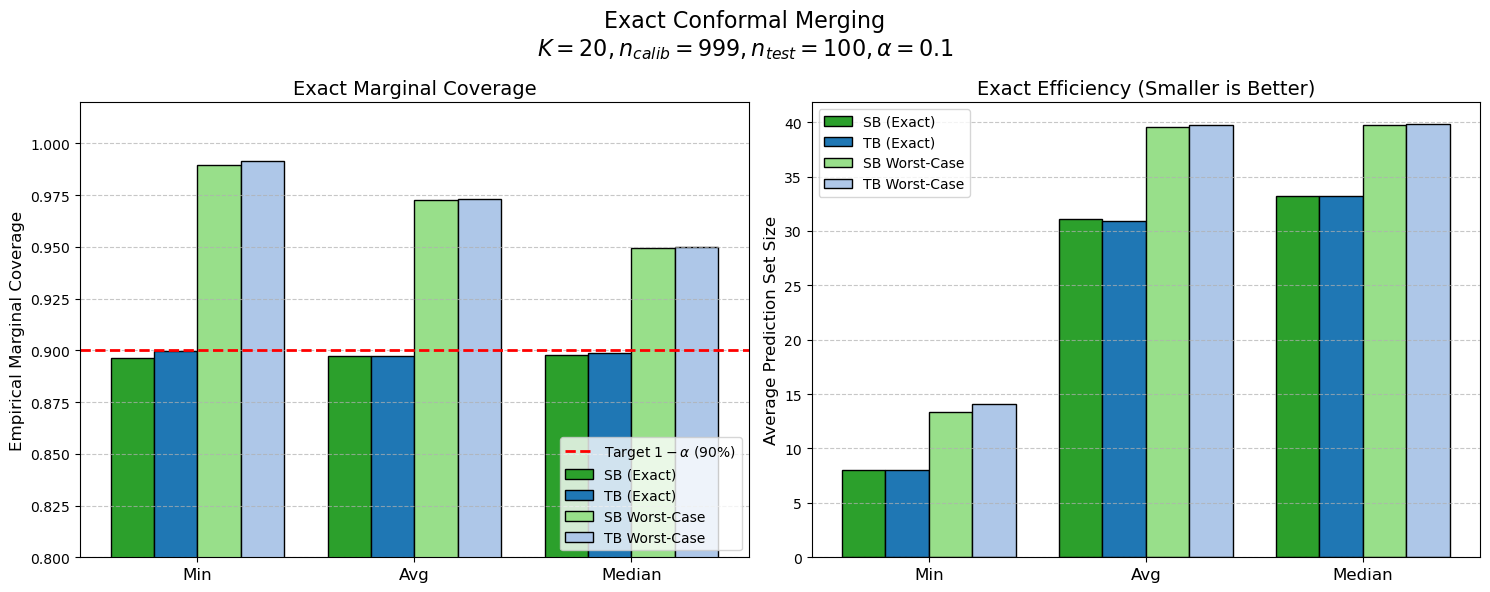

In [16]:
def run_experiment():
    n_calib = 999
    n_1 = 500
    n_test = 100
    K = 20
    alpha = 0.10
    n_trials = 1000
    
    print("=" * 80)
    print(f"Running Exact Conformal")
    print(f"n_calib={n_calib}, n_1={n_1}, n_test={n_test}, K={K}, alpha={alpha}")
    print(f"Trials={n_trials} -> Total Evaluated Test Points={n_trials * n_test}")
    print("=" * 80)
    
    key = jax.random.PRNGKey(42)
    trial_keys = jax.random.split(key, n_trials)

    @partial(jax.jit, static_argnames=['agg_func'])
    def run_all_trials(agg_func):
        def scan_step(carry, k_trial):
            k_calib, k_test = jax.random.split(k_trial)
            _, Y_cal, preds_cal = generate_data_conformal(k_calib, n_calib, K)
            _, Y_test, preds_test = generate_data_conformal(k_test, n_test, K)
            
            calib_scores = jnp.abs(Y_cal - preds_cal)
            
            def single_exact_metric(p_t, y_t):
                _, _, sb_w, sb_c = sb_exact_prediction_set(calib_scores, p_t, y_t, alpha, agg_func)
                _, _, tb_w, tb_c = tb_exact_prediction_set(calib_scores, p_t, y_t, n_1, alpha, agg_func)
                _, _, sb_wc_w, sb_wc_c = sb_worst_case_prediction_set(calib_scores, p_t, y_t, alpha, agg_func)
                _, _, tb_wc_w, tb_wc_c = tb_worst_case_prediction_set(calib_scores, p_t, y_t, n_1, alpha, agg_func)
                
                return jnp.array([sb_c, sb_wc_c, tb_c, tb_wc_c, sb_w, sb_wc_w, tb_w, tb_wc_w])
                
            metrics_batch = jax.vmap(single_exact_metric)(preds_test, Y_test[:, 0])
            return carry, jnp.mean(metrics_batch, axis=0)

        _, metrics_matrix = jax.lax.scan(scan_step, None, trial_keys)
        return jnp.mean(metrics_matrix, axis=0)

    agg_functions = ['min', 'avg', 'median']
    results = {
        'SB_Cov': [], 'SB_WC_Cov': [], 'TB_Cov': [], 'TB_WC_Cov': [],
        'SB_Wid': [], 'SB_WC_Wid': [], 'TB_Wid': [], 'TB_WC_Wid': []
    }

    for agg in agg_functions:
        print(f"Running experiment for '{agg}'...")
        avg_metrics = run_all_trials(agg)
        results['SB_Cov'].append(float(avg_metrics[0]))
        results['SB_WC_Cov'].append(float(avg_metrics[1]))
        results['TB_Cov'].append(float(avg_metrics[2]))
        results['TB_WC_Cov'].append(float(avg_metrics[3]))
        
        results['SB_Wid'].append(float(avg_metrics[4]))
        results['SB_WC_Wid'].append(float(avg_metrics[5]))
        results['TB_Wid'].append(float(avg_metrics[6]))
        results['TB_WC_Wid'].append(float(avg_metrics[7]))

    print("\n" + "=" * 80)
    print(f"EXPERIMENT RESULTS: EXACT MARGINAL COVERAGE (Target > {1-alpha:.2f})")
    print("=" * 80)
    print(f"{'Agg Func':<10} | {'SB (Exact)':<12} | {'SB Worst-Case':<15} | {'TB (Exact)':<12} | {'TB Worst-Case':<15}")
    print("-" * 80)
    for i, agg in enumerate(agg_functions):
        print(f"{agg.capitalize():<10} | {results['SB_Cov'][i]:<12.4f} | {results['SB_WC_Cov'][i]:<15.4f} | {results['TB_Cov'][i]:<12.4f} | {results['TB_WC_Cov'][i]:<15.4f}")

    print("\n" + "-" * 80)
    print("EXPERIMENT RESULTS: EXACT PREDICTION SET SIZE")
    print("-" * 80)
    print(f"{'Agg Func':<10} | {'SB (Exact)':<12} | {'SB Worst-Case':<15} | {'TB (Exact)':<12} | {'TB Worst-Case':<15}")
    print("-" * 80)
    for i, agg in enumerate(agg_functions):
        print(f"{agg.capitalize():<10} | {results['SB_Wid'][i]:<12.4f} | {results['SB_WC_Wid'][i]:<15.4f} | {results['TB_Wid'][i]:<12.4f} | {results['TB_WC_Wid'][i]:<15.4f}")
    print("=" * 80 + "\n")

    os.makedirs('results', exist_ok=True)
    save_path = os.path.join('results', 'experiment_6a.npz')
    np.savez(save_path, 
             agg_functions=np.array(agg_functions),
             alpha=alpha,
             SB_Cov=results['SB_Cov'],
             TB_Cov=results['TB_Cov'],
             SB_WC_Cov=results['SB_WC_Cov'],
             TB_WC_Cov=results['TB_WC_Cov'],
             SB_Wid=results['SB_Wid'],
             TB_Wid=results['TB_Wid'],
             SB_WC_Wid=results['SB_WC_Wid'],
             TB_WC_Wid=results['TB_WC_Wid'])
    print(f"Data successfully saved to: {save_path}")
    
    # Plotting
    x = np.arange(len(agg_functions))
    width = 0.2
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['#2ca02c', '#98df8a', '#1f77b4', '#aec7e8']
    
    ax1.bar(x - 1.5*width, results['SB_Cov'], width, label='SB (Exact)', color=colors[0], edgecolor='black')
    ax1.bar(x - 0.5*width, results['TB_Cov'], width, label='TB (Exact)', color=colors[2], edgecolor='black')
    ax1.bar(x + 0.5*width, results['SB_WC_Cov'], width, label='SB Worst-Case', color=colors[1], edgecolor='black')
    ax1.bar(x + 1.5*width, results['TB_WC_Cov'], width, label='TB Worst-Case', color=colors[3], edgecolor='black')
    ax1.axhline(1 - alpha, color='red', linestyle='--', linewidth=2, label=r'Target $1-\alpha$ (90%)')
    ax1.set_xticks(x); ax1.set_xticklabels([f.capitalize() for f in agg_functions], fontsize=12)
    ax1.set_ylabel('Empirical Marginal Coverage', fontsize=12); ax1.set_title('Exact Marginal Coverage', fontsize=14)
    ax1.set_ylim(0.80, 1.02); ax1.grid(axis='y', linestyle='--', alpha=0.7); ax1.legend(loc='lower right')

    ax2.bar(x - 1.5*width, results['SB_Wid'], width, label='SB (Exact)', color=colors[0], edgecolor='black')
    ax2.bar(x - 0.5*width, results['TB_Wid'], width, label='TB (Exact)', color=colors[2], edgecolor='black')
    ax2.bar(x + 0.5*width, results['SB_WC_Wid'], width, label='SB Worst-Case', color=colors[1], edgecolor='black')
    ax2.bar(x + 1.5*width, results['TB_WC_Wid'], width, label='TB Worst-Case', color=colors[3], edgecolor='black')
    ax2.set_xticks(x); ax2.set_xticklabels([f.capitalize() for f in agg_functions], fontsize=12)
    ax2.set_ylabel('Average Prediction Set Size', fontsize=12); ax2.set_title('Exact Efficiency (Smaller is Better)', fontsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.legend(loc='upper left')

    fig.suptitle(f'Exact Conformal Merging\n$K={K}, n_{{calib}}={n_calib}, n_{{test}}={n_test}, \\alpha={alpha}$', fontsize=16)
    plt.tight_layout(); plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 6b

EXACT SCALABILITY EXPERIMENT: Varying Number of Test Points
Benchmarking N_test=500 ... Done.
Benchmarking N_test=1000... Done.
Benchmarking N_test=2000... Done.
Benchmarking N_test=4000... Done.
Benchmarking N_test=8000... Done.
Benchmarking N_test=16000... Done.
Benchmarking N_test=32000... Done.

Data successfully saved to: results/experiment_6b.npz


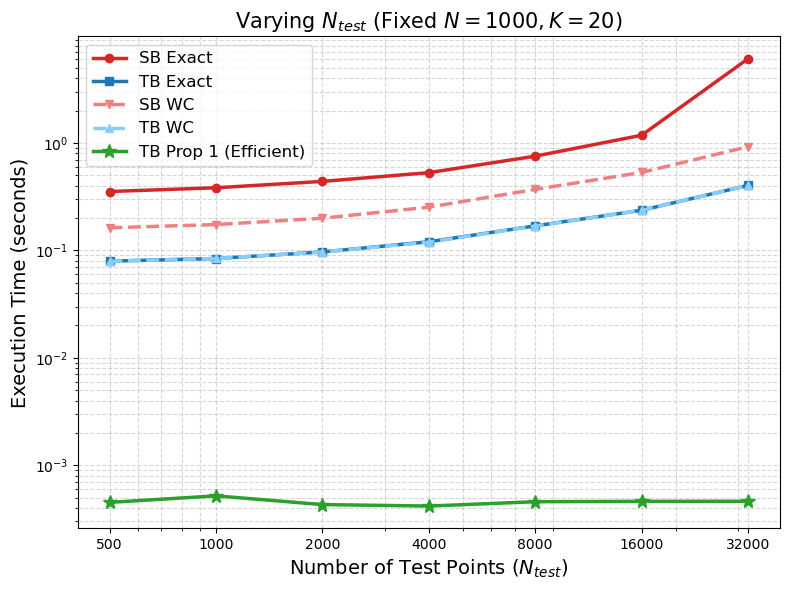

In [17]:
def run_experiment():
    n_test_values = [500, 1000, 2000, 4000, 8000, 16000, 32000] 
    alpha = 0.10
    n_timing_reps = 10 

    print("=" * 80)
    print("EXACT SCALABILITY EXPERIMENT: Varying Number of Test Points")
    print("=" * 80)

    # Wrap target functions to isolate JIT compilations (Batch N_test Points)
    @jax.jit
    def vmap_time_sb_exact(calib_scores, preds_test_arr, Y_true_arr):
        return jax.vmap(lambda p, y: sb_exact_prediction_set(calib_scores, p, y, alpha, 'min')[2])(preds_test_arr, Y_true_arr)
        
    @jax.jit
    def vmap_time_sb_wc(calib_scores, preds_test_arr, Y_true_arr):
        return jax.vmap(lambda p, y: sb_worst_case_prediction_set(calib_scores, p, y, alpha, 'min')[2])(preds_test_arr, Y_true_arr)

    @partial(jax.jit, static_argnames=['n_1'])
    def vmap_time_tb_exact(calib_scores, preds_test_arr, Y_true_arr, n_1):
        return jax.vmap(lambda p, y: tb_exact_prediction_set(calib_scores, p, y, n_1, alpha, 'min')[2])(preds_test_arr, Y_true_arr)
        
    @partial(jax.jit, static_argnames=['n_1'])
    def vmap_time_tb_wc(calib_scores, preds_test_arr, Y_true_arr, n_1):
        return jax.vmap(lambda p, y: tb_worst_case_prediction_set(calib_scores, p, y, n_1, alpha, 'min')[2])(preds_test_arr, Y_true_arr)

    @partial(jax.jit, static_argnames=['n_1'])
    def vmap_time_tb_eff(calib_scores, preds_test_arr, Y_true_arr, n_1):
        return jax.vmap(lambda p, y: tb_min_efficient(calib_scores, p, y, n_1, alpha)[0])(preds_test_arr, Y_true_arr)

    times_sb_M, times_sb_wc_M, times_tb_M, times_tb_wc_M, times_eff_M = [], [], [], [], []
    fixed_N_M = 500
    fixed_K_M = 20
    fixed_n_1_M = fixed_N_M // 2

    k_calib, k_test_base = jax.random.split(jax.random.PRNGKey(999), 2)
    _, Y_cal_M, preds_cal_M = generate_data_conformal(k_calib, fixed_N_M, fixed_K_M)
    calib_scores_M = jnp.abs(Y_cal_M - preds_cal_M)

    for m_test in n_test_values:
        print(f"Benchmarking N_test={m_test:<4}...", end=" ", flush=True)

        k_test_m = jax.random.fold_in(k_test_base, m_test)
        _, Y_test_M, preds_test_M = generate_data_conformal(k_test_m, m_test, fixed_K_M)
        Y_true_M = Y_test_M[:, 0]

        # Warm-up compilations
        _ = vmap_time_sb_exact(calib_scores_M, preds_test_M, Y_true_M).block_until_ready()
        _ = vmap_time_sb_wc(calib_scores_M, preds_test_M, Y_true_M).block_until_ready()
        _ = vmap_time_tb_exact(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready()
        _ = vmap_time_tb_wc(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready()
        _ = vmap_time_tb_eff(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready()

        t_sb, t_sb_wc, t_tb, t_tb_wc, t_eff = 0, 0, 0, 0, 0
        for _ in range(n_timing_reps):
            s = time.time(); _ = vmap_time_sb_exact(calib_scores_M, preds_test_M, Y_true_M).block_until_ready(); t_sb += time.time() - s
            s = time.time(); _ = vmap_time_sb_wc(calib_scores_M, preds_test_M, Y_true_M).block_until_ready(); t_sb_wc += time.time() - s
            s = time.time(); _ = vmap_time_tb_exact(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready(); t_tb += time.time() - s
            s = time.time(); _ = vmap_time_tb_wc(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready(); t_tb_wc += time.time() - s
            s = time.time(); _ = vmap_time_tb_eff(calib_scores_M, preds_test_M, Y_true_M, fixed_n_1_M).block_until_ready(); t_eff += time.time() - s

        times_sb_M.append(t_sb / n_timing_reps)
        times_sb_wc_M.append(t_sb_wc / n_timing_reps)
        times_tb_M.append(t_tb / n_timing_reps)
        times_tb_wc_M.append(t_tb_wc / n_timing_reps)
        times_eff_M.append(t_eff / n_timing_reps)
        print(f"Done.")

    # Save Data
    os.makedirs('results', exist_ok=True)
    save_path = os.path.join('results', 'experiment_6b.npz')
    np.savez(save_path, 
             n_test_values=np.array(n_test_values),
             times_sb_M=times_sb_M,
             times_sb_wc_M=times_sb_wc_M,
             times_tb_M=times_tb_M,
             times_tb_wc_M=times_tb_wc_M,
             times_eff_M=times_eff_M)
    print(f"\nData successfully saved to: {save_path}")
    
    # Plotting (Inline Verification)
    fig, ax3 = plt.subplots(figsize=(8, 6))
    
    ax3.plot(n_test_values, times_sb_M, marker='o', lw=2.5, color='tab:red', label='SB Exact')
    ax3.plot(n_test_values, times_tb_M, marker='s', lw=2.5, color='tab:blue', label='TB Exact')
    ax3.plot(n_test_values, times_sb_wc_M, marker='v', lw=2.5, color='lightcoral', linestyle='--', label='SB WC')
    ax3.plot(n_test_values, times_tb_wc_M, marker='^', lw=2.5, color='lightskyblue', linestyle='--', label='TB WC')
    ax3.plot(n_test_values, times_eff_M, marker='*', lw=2.5, markersize=10, color='tab:green', label='TB Prop 1 (Efficient)')
    
    ax3.set_xlabel('Number of Test Points ($N_{test}$)', fontsize=14)
    ax3.set_ylabel('Execution Time (seconds)', fontsize=14)
    ax3.set_title(f'Varying $N_{{test}}$ (Fixed $N=1000, K=20$)', fontsize=15)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_xticks(n_test_values)
    ax3.set_xticklabels([str(val) for val in n_test_values])
    ax3.grid(True, which="both", ls="--", alpha=0.5)
    ax3.legend(loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 7a

Running Power Experiment: MaxT vs SB vs TB
Benchmarking scale = 0.00...
Benchmarking scale = 0.20...
Benchmarking scale = 0.40...
Benchmarking scale = 0.60...
Benchmarking scale = 0.80...
Benchmarking scale = 1.00...

Data successfully saved to: results/experiment_7a.npz


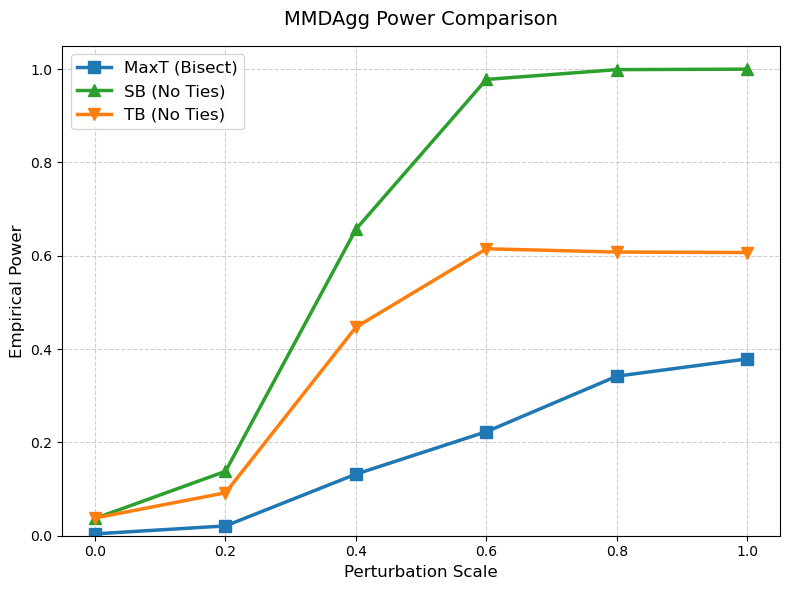

In [18]:
def run_experiment():
    repetitions = 1000
    sample_size = 500
    scales = (0, 0.2, 0.4, 0.6, 0.8, 1.0)
    num_perturbations = 2  
    d = 1                  
    alpha = 0.05
    B = 199            

    key = jax.random.PRNGKey(42)
    
    # 3 outputs from mmdagg_all:
    # 0: MaxT_Bisect, 1: SB_No_Ties, 2: TB_No_Ties
    outputs = np.zeros((3, len(scales), repetitions))

    print("=" * 80)
    print("Running Power Experiment: MaxT vs SB vs TB")
    print("=" * 80)

    for s_idx, scale in enumerate(scales):
        print(f"Benchmarking scale = {scale:.2f}...")
        key, subkey = jax.random.split(key)
        
        X_all, Y_all = sampler_perturb_2ST(
            key=subkey,
            m=sample_size,
            n=sample_size,
            d=d,
            num_random=repetitions,
            num_perturbations=num_perturbations,
            scale=scale,
        )
        
        for i in range(repetitions):
            X = X_all[i]
            Y = Y_all[i]
            
            key, subkey = jax.random.split(key)
            
            res = mmdagg_all(subkey, (X, Y), B=B, alpha=alpha)
            
            for t in range(3):
                outputs[t, s_idx, i] = res[t]
                
    power = np.mean(outputs, axis=-1)
    
    os.makedirs("results", exist_ok=True)
    save_path = os.path.join("results", "experiment_7a.npz")
    np.savez(save_path, scales=np.array(scales), power=power)
    print(f"\nData successfully saved to: {save_path}")

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    linewidth = 2.5
    markersize = 8
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    ax.plot(scales, power[0], label='MaxT (Bisect)', marker='s', lw=linewidth, ms=markersize, color=colors[0])
    ax.plot(scales, power[1], label='SB (No Ties)', marker='^', lw=linewidth, ms=markersize, color=colors[1])
    ax.plot(scales, power[2], label='TB (No Ties)', marker='v', lw=linewidth, ms=markersize, color=colors[2])
    
    ax.set_title('MMDAgg Power Comparison', fontsize=14, pad=15)
    ax.set_xlabel('Perturbation Scale', fontsize=12)
    ax.set_ylabel('Empirical Power', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Positioning legend cleanly in the upper left
    ax.legend(fontsize=12, loc='upper left')
        
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()

# Experiment 7b

Running Power Experiment: MaxT vs SB vs TB
Benchmarking scale = 0.00...
Benchmarking scale = 0.20...
Benchmarking scale = 0.40...
Benchmarking scale = 0.60...
Benchmarking scale = 0.80...
Benchmarking scale = 1.00...

Data successfully saved to: results/experiment_7b.npz


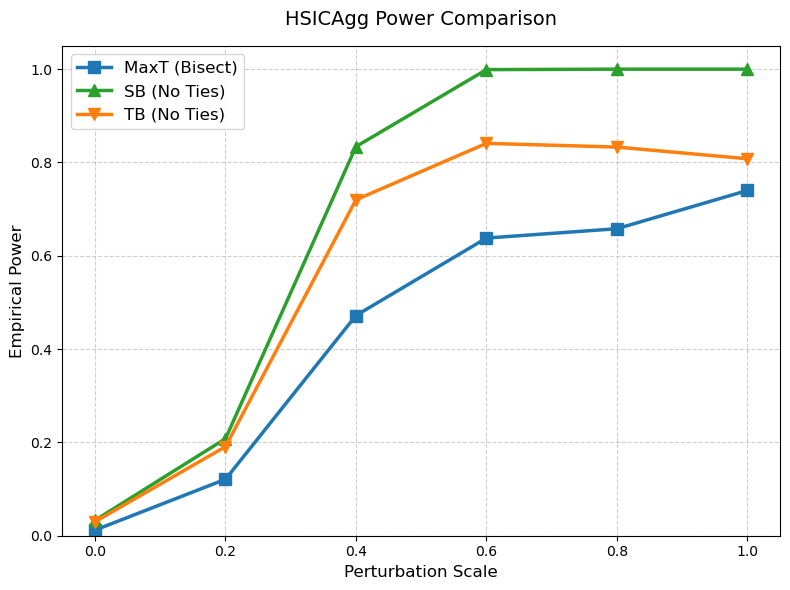

In [19]:
def run_experiment():
    repetitions = 1000
    sample_size = 500
    scales = (0, 0.2, 0.4, 0.6, 0.8, 1.0)
    num_perturbations = 1  
    dX = 1
    dY = 1              
    alpha = 0.05
    B = 199              

    key = jax.random.PRNGKey(42)
    
    # 3 outputs from hsicagg_all:
    # 0: MaxT_Bisect, 1: SB_No_Ties, 2: TB_No_Ties
    outputs = np.zeros((3, len(scales), repetitions))

    print("=" * 80)
    print("Running Power Experiment: MaxT vs SB vs TB")
    print("=" * 80)

    for s_idx, scale in enumerate(scales):
        print(f"Benchmarking scale = {scale:.2f}...")
        key, subkey = jax.random.split(key)
        
        X_all, Y_all = sampler_perturb_IndT(
            key=subkey,
            m=sample_size,
            dX=dX,
            dY=dY,
            num_random=repetitions,
            num_perturbations=num_perturbations,
            scale=scale,
        )
        
        for i in range(repetitions):
            X = X_all[i]
            Y = Y_all[i]
            
            key, subkey = jax.random.split(key)
            
            res = hsicagg_all(subkey, (X, Y), B=B, alpha=alpha)
            
            for t in range(3):
                outputs[t, s_idx, i] = res[t]
                
    power = np.mean(outputs, axis=-1)
    
    os.makedirs("results", exist_ok=True)
    save_path = os.path.join("results", "experiment_7b.npz")
    np.savez(save_path, scales=np.array(scales), power=power)
    print(f"\nData successfully saved to: {save_path}")

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    linewidth = 2.5
    markersize = 8
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    ax.plot(scales, power[0], label='MaxT (Bisect)', marker='s', lw=linewidth, ms=markersize, color=colors[0])
    ax.plot(scales, power[1], label='SB (No Ties)', marker='^', lw=linewidth, ms=markersize, color=colors[1])
    ax.plot(scales, power[2], label='TB (No Ties)', marker='v', lw=linewidth, ms=markersize, color=colors[2])
    
    ax.set_title('HSICAgg Power Comparison', fontsize=14, pad=15)
    ax.set_xlabel('Perturbation Scale', fontsize=12)
    ax.set_ylabel('Empirical Power', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.legend(fontsize=12, loc='upper left')
        
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_experiment()